# PTARF — Procedure and Implementation
### An Identity-based Permission- and Trust-Aware Retrieval Framework for Dynamic Cloud Environments

**Authors:** Urvashi Rahul Saxena, Rajkumar Buyya, Ramin Karim, Ravdeep Kour

## What this notebook does
It regenerates the synthetic benchmark, runs PTARF and every baseline, and produces **every table and figure of the revised manuscript. No result is typed in: all numbers are computed by the code below and written to `results/`.** Part 2 ends with a check that compares the computed values with those reported in the manuscript.

| Step | What runs | Manuscript item |
|---|---|---|
| 3 | Benchmark generator (`generate_data.py`) and its integrity checks (`validate_dataset.py`) | Section 4.2, Table 5 |
| 4 | All models, ablations, threshold and stealth sensitivity (`run_experiments.py`) | Tables 7, 8 and 10, Figs. 2–6 |
| 5 | Per-request Algorithms 1 and 2 (`ptarf_algorithms.py`) and agreement check with the batch evaluator | Section 3.7, Algorithms 1–2 |
| 6 | Permission-scoped retrieval experiment | Table 11, Fig. 7 |
| 7 | Continuous-monitoring experiment (online profile updates) | Table 12 |
| 7b | Additional checks on the design of the behavioural trust: smoothing width, dropping each attribute, random attribute weights (`sensitivity_trust.py`) | Additional checks, not reported in the tables |
| 7c | Which of the four trust components B, H, C, E carry signal (`trust_components.py`) | Table 9, Section 5.3 |
| 7d | Monitoring and revocation with the number of permissible resource requests NOPRR (`revocation_experiment.py`) | Section 5.7 (revocation test) |
| 7e | Sensitivity of that rule to NOPRR, window, m_min and rho (`revocation_sensitivity.py`) | Additional checks, not reported in the tables |
| 8 | Latency and index size; worked examples; gate + learned-trust check | Table 13 and Table 4, Section 5.1 |

**Modes.** `QUICK = True` (default) uses 2 seeds and fewer sensitivity levels (typically 10–25 min on a CPU runtime) and is meant to show that the pipeline runs. `QUICK = False` uses the 5 seeds reported in the manuscript (typically 45–90 min; the time depends on the runtime).

**Not executed for any reported number:** the LLM explanation stage. Decisions never depend on it. An optional cell at the end shows how to attach Llama-3 for explanations.

**Retrieval** uses TF-IDF (scikit-learn), not neural embeddings. **Latency** figures depend on the machine and will differ from the manuscript's.

## Step 1 — Install dependencies

In [1]:
!pip install numpy pandas scipy scikit-learn matplotlib -q
print('Dependencies ready.')
import sys, platform, numpy, pandas, scipy, sklearn
print('Environment (record these in the paper):')
print('Python', sys.version.split()[0], '|', platform.platform())
print('NumPy', numpy.__version__, '| pandas', pandas.__version__, '| SciPy', scipy.__version__, '| scikit-learn', sklearn.__version__)
print('Hardware (record these in the paper):')
!lscpu | grep 'Model name'
!nproc
!free -h

Dependencies ready.
Environment (record these in the paper):
Python 3.13.16 | Linux-6.6.122+-x86_64-with-glibc2.39
NumPy 2.1.3 | pandas 2.2.3 | SciPy 1.16.3 | scikit-learn 1.6.1
Hardware (record these in the paper):
Model name:                              Intel(R) Xeon(R) CPU @ 2.20GHz
2
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.3Gi       8.2Gi       2.3Mi       3.4Gi        11Gi
Swap:             0B          0B          0B


## Step 2 — Setup

In [2]:
import os, sys, json, time, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from IPython.display import Image, display

QUICK = False     # set to False to reproduce the five-seed results reported in the manuscript
os.environ['PTARF_QUICK'] = '1' if QUICK else '0'
os.makedirs('results', exist_ok=True)
print('Mode:', 'QUICK (2 seeds)' if QUICK else 'FULL (5 seeds)')

Mode: FULL (5 seeds)


## Step 3 — Write the source files
Each cell below writes one module to disk (`%%writefile`). They are the exact files used for the manuscript.

In [3]:
%%writefile generate_data.py
"""
PTARF synthetic benchmark generator (v2).

Key property: ground-truth labels come from the *scenario* each request was
drawn from (legitimate vs. a named attack/violation type), never from any
trust formula. Scoring models only see observable request features.

Scenarios (label):
  routine          legit   permitted resource the user habitually uses
  novel_task       legit   permitted resource the user has never used (hard for B)
  travel           legit   permitted habitual resource from new location/device (hard for B)
  out_of_policy    deny    (role, resource, action) not in ACL
  inactive_account deny    suspended/revoked account
  condition_viol   deny    ACL entry exists but a condition (hours/MFA/channel) fails
  compromised      deny    stolen credentials: valid ACL, anomalous context;
                           a fraction are 'stealthy' and mimic the victim
  insider_exfil    deny    own habitual resources, bulk download/delete bursts
"""
import argparse, json, os
import numpy as np
import pandas as pd

DEPTS = ["Finance", "Human Resources", "Cloud Operations", "Security", "Engineering",
         "Legal", "Sales", "Procurement", "Research", "Support"]
ROLES = [  # (role, dept)
    ("Finance Analyst", "Finance"), ("HR Manager", "Human Resources"),
    ("Cloud Administrator", "Cloud Operations"), ("Security Analyst", "Security"),
    ("Software Engineer", "Engineering"), ("DevOps Engineer", "Engineering"),
    ("Legal Advisor", "Legal"), ("Sales Executive", "Sales"),
    ("Procurement Officer", "Procurement"), ("Research Scientist", "Research"),
    ("Support Agent", "Support"), ("Auditor", "Finance")]
ACTIONS = ["Read", "Write", "Download", "Upload", "Delete", "Modify", "Execute", "Approve"]
RISKY = {"Download", "Delete", "Execute"}
CONDS = ["None", "Working_Hours", "MFA_Required", "Secure_Channel"]
LOCS = [f"LOC{i:02d}" for i in range(30)]
DEVS = [f"DEV{i:03d}" for i in range(400)]

MIX = {"routine": .58, "novel_task": .10, "travel": .04, "out_of_policy": .08,
       "inactive_account": .03, "condition_viol": .05, "compromised": .08,
       "insider_exfil": .04}
LEGIT = {"routine", "novel_task", "travel"}


def build_world(rng):
    res = []
    for d in DEPTS:
        for k in range(5):
            sens = rng.choice(["Internal", "Confidential", "Restricted"], p=[.4, .4, .2])
            res.append({"Resource": f"{d.replace(' ', '')}_R{k+1}", "Department": d,
                        "Sensitivity": sens})
    res = pd.DataFrame(res)
    acl = []
    for role, dept in ROLES:
        own = res[res.Department == dept].Resource.tolist()
        other = res[res.Department != dept].sample(3, random_state=rng.integers(1e9)).Resource.tolist()
        for r in own + other:
            sens = res.set_index("Resource").Sensitivity[r]
            n_act = rng.integers(1, 4)
            acts = rng.choice(ACTIONS, n_act, replace=False)
            for a in acts:
                cond = rng.choice(CONDS, p=[.35, .25, .25, .15] if sens != "Restricted" else [.0, .3, .5, .2])
                acl.append({"Role": role, "Resource": r, "Action": a, "Condition": cond})
    acl = pd.DataFrame(acl).drop_duplicates(["Role", "Resource", "Action"])
    return res, acl


def build_users(rng, n_users, acl):
    users = []
    roles = [r for r, _ in ROLES]
    for i in range(n_users):
        role = roles[rng.integers(len(roles))]
        perms = acl[acl.Role == role][["Resource", "Action"]].values.tolist()
        k = max(2, int(len(perms) * rng.uniform(.3, .6)))
        habit_idx = rng.choice(len(perms), k, replace=False)
        habit = [perms[j] for j in habit_idx]
        w = rng.dirichlet(np.ones(k) * .7)
        status = rng.choice(["Active", "Suspended", "Revoked"], p=[.95, .03, .02])
        shift_start = int(rng.choice([7, 8, 9, 10], p=[.1, .4, .4, .1]))
        users.append({
            "User_ID": f"U{i+1:05d}", "Role": role, "Status": status,
            "Home_Loc": LOCS[rng.integers(len(LOCS))],
            "Devices": list(rng.choice(DEVS, rng.integers(1, 3), replace=False)),
            "Shift_Start": shift_start, "Habit": habit, "Habit_W": w.tolist(),
            "Rate": float(rng.gamma(2.0, 1.0)),  # typical requests/hour when active
        })
    return users


def hour_in_shift(rng, u, off=False):
    if off:
        return int(rng.choice(list(range(0, 6)) + list(range(20, 24))))
    return int(np.clip(rng.normal(u["Shift_Start"] + 4, 2.2), 0, 23))


def gen_history(rng, users, days=120, per_user_mean=40):
    rows = []
    t0 = pd.Timestamp("2025-01-01")
    for u in users:
        n = rng.poisson(per_user_mean)
        for _ in range(n):
            j = rng.choice(len(u["Habit"]), p=u["Habit_W"])
            r, a = u["Habit"][j]
            day = rng.integers(days)
            h = hour_in_shift(rng, u)
            loc = u["Home_Loc"] if rng.random() > .05 else LOCS[rng.integers(len(LOCS))]
            dev = u["Devices"][rng.integers(len(u["Devices"]))]
            ok = rng.random() > .04
            rows.append({"User_ID": u["User_ID"], "Timestamp": t0 + pd.Timedelta(days=int(day), hours=h,
                         minutes=int(rng.integers(60))), "Resource": r, "Action": a,
                         "Location": loc, "Device": dev, "Status": "Success" if ok else "Failed"})
    return pd.DataFrame(rows).sort_values("Timestamp").reset_index(drop=True)


def gen_requests(rng, users, acl, res, n_req, stealth_frac=.3, days=60):
    t0 = pd.Timestamp("2025-05-01")
    acl_idx = acl.set_index(["Role", "Resource", "Action"]).Condition.to_dict()
    by_role = {r: g for r, g in acl.groupby("Role")}
    active = [u for u in users if u["Status"] == "Active"]
    inactive = [u for u in users if u["Status"] != "Active"]
    scen = rng.choice(list(MIX), n_req, p=list(MIX.values()))
    rows = []
    all_res = res.Resource.tolist()
    for i, s in enumerate(scen):
        u = (inactive if s == "inactive_account" else active)[
            rng.integers(len(inactive if s == "inactive_account" else active))]
        loc, dev = u["Home_Loc"], u["Devices"][rng.integers(len(u["Devices"]))]
        mfa, secure, burst = True, True, rng.poisson(u["Rate"])
        off = False
        if s in ("routine", "inactive_account", "travel", "insider_exfil"):
            j = rng.choice(len(u["Habit"]), p=u["Habit_W"]); r, a = u["Habit"][j]
        elif s in ("novel_task", "compromised", "condition_viol"):
            perms = by_role[u["Role"]][["Resource", "Action"]].values.tolist()
            habit = {tuple(x) for x in u["Habit"]}
            cand = [p for p in perms if tuple(p) not in habit] or perms
            if s == "compromised" and rng.random() < stealth_frac:
                j = rng.choice(len(u["Habit"]), p=u["Habit_W"]); r, a = u["Habit"][j]
            else:
                r, a = cand[rng.integers(len(cand))]
        elif s == "out_of_policy":
            while True:
                r, a = all_res[rng.integers(len(all_res))], ACTIONS[rng.integers(len(ACTIONS))]
                if (u["Role"], r, a) not in acl_idx: break
        if s == "travel":
            loc = LOCS[rng.integers(len(LOCS))]; dev = DEVS[rng.integers(len(DEVS))]
        if s == "compromised":
            stealthy = rng.random() < stealth_frac
            if not stealthy:
                loc = LOCS[rng.integers(len(LOCS))] if rng.random() < .8 else loc
                dev = DEVS[rng.integers(len(DEVS))] if rng.random() < .8 else dev
                off = rng.random() < .5
                burst = burst + rng.poisson(6)
        if s == "insider_exfil":
            a = rng.choice(["Download", "Delete"], p=[.8, .2])
            burst = burst + rng.poisson(10)
            off = rng.random() < .3
        cond = acl_idx.get((u["Role"], r, a), "NA")
        if s == "condition_viol":
            viol = [c for c in [cond] if c != "None"]
            if not viol:  # pick an ACL entry that has a condition
                g = by_role[u["Role"]]; g = g[g.Condition != "None"]
                row = g.iloc[rng.integers(len(g))]; r, a, cond = row.Resource, row.Action, row.Condition
            if cond == "Working_Hours": off = True
            elif cond == "MFA_Required": mfa = False
            elif cond == "Secure_Channel": secure = False
        else:
            # legit traffic satisfies conditions; non-condition attacks mostly do too
            if cond == "Working_Hours" and s in LEGIT: off = False
            if s not in LEGIT and s != "condition_viol":
                mfa = rng.random() > .1; secure = rng.random() > .1
            elif rng.random() < .15:  # benign: MFA/secure not needed but sometimes absent
                if cond not in ("MFA_Required",): mfa = rng.random() > .5
        h = hour_in_shift(rng, u, off)
        if cond == "Working_Hours" and s in LEGIT: h = int(np.clip(h, 9, 16))
        day = rng.integers(days)
        rows.append({"Request_ID": f"REQ{i+1:06d}", "User_ID": u["User_ID"], "Role": u["Role"],
                     "Account_Status": u["Status"], "Resource": r, "Action": a,
                     "Timestamp": t0 + pd.Timedelta(days=int(day), hours=h, minutes=int(rng.integers(60))),
                     "Location": loc, "Device": dev, "MFA": bool(mfa), "Secure_Channel": bool(secure),
                     "Recent_Request_Rate": int(burst),
                     "Scenario": s, "Ground_Truth": "Allow" if s in LEGIT else "Deny"})
    return pd.DataFrame(rows).sort_values("Timestamp").reset_index(drop=True)


def policy_docs(acl):
    docs = []
    for i, p in acl.reset_index(drop=True).iterrows():
        c = {"None": "no additional condition", "Working_Hours": "only during working hours 09:00-17:00",
             "MFA_Required": "only with multi-factor authentication",
             "Secure_Channel": "only over a secure encrypted channel"}[p.Condition]
        docs.append({"Doc_ID": f"POL{i+1:04d}", "Role": p.Role, "Resource": p.Resource, "Action": p.Action,
                     "Condition": p.Condition,
                     "Text": f"Users in role {p.Role} may {p.Action.lower()} resource {p.Resource} {c}."})
    return pd.DataFrame(docs)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--seed", type=int, default=0)
    ap.add_argument("--users", type=int, default=5000)
    ap.add_argument("--requests", type=int, default=50000)
    ap.add_argument("--stealth", type=float, default=.3)
    ap.add_argument("--out", default="data")
    a = ap.parse_args()
    rng = np.random.default_rng(a.seed)
    os.makedirs(a.out, exist_ok=True)
    res, acl = build_world(rng)
    users = build_users(rng, a.users, acl)
    hist = gen_history(rng, users)
    req = gen_requests(rng, users, acl, res, a.requests, a.stealth)
    res.to_csv(f"{a.out}/resources.csv", index=False)
    acl.to_csv(f"{a.out}/acl_policies.csv", index=False)
    policy_docs(acl).to_csv(f"{a.out}/policy_documents.csv", index=False)
    pd.DataFrame([{k: (json.dumps(v) if isinstance(v, list) else v) for k, v in u.items()} for u in users]
                 ).to_csv(f"{a.out}/users.csv", index=False)
    hist.to_csv(f"{a.out}/behaviour_history.csv", index=False)
    req.to_csv(f"{a.out}/requests.csv", index=False)
    print(f"seed={a.seed} users={len(users)} acl={len(acl)} history={len(hist)} requests={len(req)}")
    print(req.Scenario.value_counts().to_string())


if __name__ == "__main__":
    main()


Writing generate_data.py


In [4]:
%%writefile evaluate.py
"""
PTARF evaluation pipeline (non-LLM components).

Models compared (positive class = Allow):
  RBAC               allow iff (role, resource, action) in ACL
  ABAC               RBAC + ACL condition satisfied + account active
  TBAC               trust only (B, H), no policy check; threshold tuned on validation
  RAG-only           allow iff the top-1 retrieved policy document authorizes the request
  AdditiveTrust-default    T = .25(B+H+C+E) >= 0.6
  AdditiveTrust-tuned    same score, threshold tuned on validation
  PTARF    hard ABAC gate, then T' = a*B + (1-a)*H >= tau (a, tau tuned on validation)
  Ablations          gate+B only, gate+H only
  LogReg (reference) supervised logistic regression on all features, trained on validation

Split: time-ordered; first 30% of requests = validation (tuning), last 70% = test.
Behaviour profiles are built from the separate history log only.
"""
import argparse, json, time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

FACETS = ["Resource", "Action", "Location", "Device"]


def load(d):
    return (pd.read_csv(f"{d}/requests.csv", parse_dates=["Timestamp"]),
            pd.read_csv(f"{d}/behaviour_history.csv", parse_dates=["Timestamp"]),
            pd.read_csv(f"{d}/acl_policies.csv", keep_default_na=False), pd.read_csv(f"{d}/policy_documents.csv"))


def policy_features(req, acl):
    key = acl.set_index(["Role", "Resource", "Action"]).Condition
    rr = set(zip(acl.Role, acl.Resource))
    cond = [key.get((a, b, c), None) for a, b, c in zip(req.Role, req.Resource, req.Action)]
    req["In_ACL"] = [c is not None for c in cond]
    req["ACL_Condition"] = [c if c is not None else "NA" for c in cond]
    h = req.Timestamp.dt.hour
    ok = np.ones(len(req), bool)
    ok &= ~((req.ACL_Condition == "Working_Hours") & ~((h >= 9) & (h < 17)))
    ok &= ~((req.ACL_Condition == "MFA_Required") & ~req.MFA)
    ok &= ~((req.ACL_Condition == "Secure_Channel") & ~req.Secure_Channel)
    req["Cond_OK"] = ok & req.In_ACL
    req["Active"] = req.Account_Status == "Active"
    # C(u) exactly as in the manuscript: share of {role, resource, action, condition} matches
    role_m = req.Role.isin(acl.Role)
    res_m = pd.Series([(a, b) in rr for a, b in zip(req.Role, req.Resource)], index=req.index)
    req["C"] = (role_m.astype(float) + res_m + req.In_ACL + req.Cond_OK) / 4
    req["Role_Match"], req["Res_Match"] = role_m.values, res_m.values
    return req


def behaviour_B(req, hist, val_mask):
    comps = []
    for f in FACETS:
        c = hist.groupby(["User_ID", f]).size().rename("c").reset_index()
        m = c.groupby("User_ID").c.max().rename("m")
        c = c.merge(m, on="User_ID"); c["s"] = c.c / c.m
        s = req[["User_ID", f]].merge(c[["User_ID", f, "s"]], on=["User_ID", f], how="left").s.fillna(0).values
        req[f"B_{f}"] = s; comps.append(f"B_{f}")
    # hour-of-day profile, circularly smoothed
    hh = np.zeros((1, 24))
    H = hist.assign(h=hist.Timestamp.dt.hour).groupby(["User_ID", "h"]).size().unstack(fill_value=0)
    H = H.reindex(columns=range(24), fill_value=0).astype(float)
    k = np.exp(-0.5 * (np.minimum(np.arange(24), 24 - np.arange(24)) / 1.5) ** 2)
    sm = np.real(np.fft.ifft(np.fft.fft(H.values, axis=1) * np.fft.fft(k)[None, :], axis=1))
    sm = sm / sm.max(axis=1, keepdims=True)
    idx = {u: i for i, u in enumerate(H.index)}
    req["B_Hour"] = [sm[idx[u], h] if u in idx else 0 for u, h in zip(req.User_ID, req.Timestamp.dt.hour)]
    # request-rate: 1 - empirical CDF over validation traffic
    v = np.sort(req.loc[val_mask, "Recent_Request_Rate"].values)
    req["B_Rate"] = 1 - np.searchsorted(v, req.Recent_Request_Rate.values, side="right") / len(v)
    comps += ["B_Hour", "B_Rate"]
    req["B"] = req[comps].mean(axis=1)
    return req, comps


def historical_H(req, hist):
    g = hist.assign(ok=hist.Status == "Success").groupby("User_ID").ok.agg(["sum", "count"])
    Hs = (g["sum"] + 1) / (g["count"] + 2)  # Laplace; uses history only, never current requests
    req["H"] = req.User_ID.map(Hs).fillna(0.5).values
    return req


def retrieval(req, docs, k=3):
    vec = TfidfVectorizer().fit(docs.Text)
    D = vec.transform(docs.Text)
    q = [f"Users in role {r} may {a.lower()} resource {s}." for r, a, s in zip(req.Role, req.Action, req.Resource)]
    Q = vec.transform(q)
    top1 = np.empty(len(req), int); E = np.empty(len(req))
    for i in range(0, len(req), 5000):
        S = (Q[i:i + 5000] @ D.T).toarray()
        part = np.argpartition(-S, k, axis=1)[:, :k]
        E[i:i + 5000] = np.take_along_axis(S, part, 1).mean(1)
        top1[i:i + 5000] = S.argmax(1)
    d = docs.iloc[top1]
    req["E"] = E  # manuscript's E(u): mean top-k similarity
    req["RAG_Authorizes"] = ((d.Role.values == req.Role.values) & (d.Resource.values == req.Resource.values)
                             & (d.Action.values == req.Action.values))
    return req


def metrics(y, p, scen):
    y, p = np.asarray(y), np.asarray(p)
    tp = np.sum(p & y); tn = np.sum(~p & ~y); fp = np.sum(p & ~y); fn = np.sum(~p & y)
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    out = {"Accuracy": (tp + tn) / len(y), "Balanced_Acc": .5 * (rec + tn / max(tn + fp, 1)),
           "Precision": prec, "Recall": rec, "F1": 2 * prec * rec / max(prec + rec, 1e-12),
           "FAR": fp / max(fp + tn, 1), "FRR": fn / max(fn + tp, 1)}
    for s in np.unique(scen):
        m = scen == s
        out[f"err_{s}"] = float(np.mean(p[m] != y[m]))  # attacks: share allowed; legit: share denied
    return out


def tune_threshold(score, y):
    best = (-1, .5)
    for t in np.linspace(0, 1, 201):
        p = score >= t
        ba = .5 * (np.mean(p[y]) + np.mean(~p[~y]))
        best = max(best, (ba, t))
    return best[1]


def run(d):
    req, hist, acl, docs = load(d)
    n = len(req); val = np.zeros(n, bool); val[: int(.3 * n)] = True; test = ~val
    t0 = time.perf_counter()
    req = policy_features(req, acl)
    req, bcomps = behaviour_B(req, hist, val)
    req = historical_H(req, hist)
    req = retrieval(req, docs)
    per_req_ms = (time.perf_counter() - t0) / n * 1000
    y = (req.Ground_Truth == "Allow").values
    gate = (req.In_ACL & req.Cond_OK & req.Active).values
    preds, info = {}, {}
    preds["RBAC"] = req.In_ACL.values
    preds["ABAC"] = gate
    tb = ((req.B + req.H) / 2).values
    t = tune_threshold(tb[val], y[val]); preds["TBAC"] = tb >= t; info["TBAC_tau"] = t
    preds["RAG-only"] = req.RAG_Authorizes.values
    T = (.25 * (req.B + req.H + req.C + req.E)).values
    preds["AdditiveTrust-default"] = T >= .6
    t = tune_threshold(T[val], y[val]); preds["AdditiveTrust-tuned"] = T >= t; info["AdditiveTrust_tau"] = t
    # corrected: gate first, then trust among gate-passing requests
    g = gate & val
    best = (-1, None)
    for a in np.linspace(0, 1, 11):
        s = a * req.B.values + (1 - a) * req.H.values
        tau = tune_threshold(np.where(gate, s, -1)[val], y[val])
        p = gate & (s >= tau)
        ba = .5 * (np.mean(p[val & y]) + np.mean(~p[val & ~y]))
        best = max(best, (ba, (a, tau)))
    a, tau = best[1]; info.update(corrected_alpha=a, corrected_tau=tau)
    preds["PTARF"] = gate & (a * req.B.values + (1 - a) * req.H.values >= tau)
    tB = tune_threshold(np.where(gate, req.B.values, -1)[val], y[val]); preds["Abl: gate+B"] = gate & (req.B.values >= tB)
    tH = tune_threshold(np.where(gate, req.H.values, -1)[val], y[val]); preds["Abl: gate+H"] = gate & (req.H.values >= tH)
    # Trust-weighted ABAC (soft policy compliance, tuned weights): S = w*A + (1-w)*(a*B + (1-a)*H),
    # A = mean of five attribute checks (role, resource, action-in-ACL, condition, account active).
    A = ((req.Role_Match.astype(float) + req.Res_Match + req.In_ACL + req.Cond_OK + req.Active) / 5).values
    best = (-1, None)
    for w in np.linspace(0, 1, 11):
        for a_ in (0, .25, .5, .75, 1):
            S = w * A + (1 - w) * (a_ * req.B.values + (1 - a_) * req.H.values)
            tau_ = tune_threshold(S[val], y[val]); p = S >= tau_
            ba = .5 * (np.mean(p[val & y]) + np.mean(~p[val & ~y]))
            if ba > best[0] + 1e-9: best = (ba, (w, a_, tau_))
    w, a_, tau_ = best[1]; info.update(tw_w=w, tw_a=a_, tw_tau=tau_)
    S = w * A + (1 - w) * (a_ * req.B.values + (1 - a_) * req.H.values); preds["TW-ABAC (tuned additive)"] = S >= tau_
    X = np.column_stack([req.In_ACL, req.Cond_OK, req.Active, req[bcomps].values, req.H, req.C, req.E]).astype(float)
    sc = StandardScaler().fit(X[val]); lr = LogisticRegression(max_iter=2000, class_weight="balanced")
    lr.fit(sc.transform(X[val]), y[val]); preds["LogReg (supervised ref.)"] = lr.predict(sc.transform(X)).astype(bool)
    gb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, class_weight="balanced", random_state=0)
    gb.fit(X[val], y[val]); preds["GBDT (supervised ref.)"] = gb.predict(X).astype(bool)
    preds["Gate + learned trust (supplementary)"] = gate & preds["GBDT (supervised ref.)"]
    scen = req.Scenario.values
    res = {m: metrics(y[test], p[test], scen[test]) for m, p in preds.items()}
    # threshold sensitivity for the additive trust score
    sens = {f"{t:.2f}": metrics(y[test], (T >= t)[test], scen[test]) for t in np.arange(.4, .81, .05)}
    return res, sens, info, per_req_ms, req


if __name__ == "__main__":
    ap = argparse.ArgumentParser(); ap.add_argument("--data", default="data_s0"); a = ap.parse_args()
    res, sens, info, ms, _ = run(a.data)
    print(json.dumps(info)); print(f"feature pipeline: {ms:.4f} ms/request (excl. LLM)")
    print(pd.DataFrame(res).T.round(3).to_string())


Writing evaluate.py


In [5]:
%%writefile ptarf_algorithms.py
"""Per-request implementation of PTARF Algorithm 1 (RRAC hard gate) and Algorithm 2 (scoped evidence, trust components,
total trust T = alpha*B + beta*H + gamma*C + delta*E, decision, explanation prompt, monitoring update).  Evaluated configuration:
gamma = delta = 0 and beta = 1 - alpha.  The batch evaluator in evaluate.py implements the same maths vectorised; the notebook checks
that the two agree request by request."""
import numpy as np, pandas as pd
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer

FACETS = ["Resource", "Action", "Location", "Device"]
_K = np.array([[np.exp(-0.5 * (min((i - j) % 24, 24 - (i - j) % 24) / 1.5) ** 2) for j in range(24)] for i in range(24)])


class PTARF:
    def __init__(self, data_dir, alpha, tau, gamma=0.0, delta=0.0):
        self.alpha, self.gamma, self.delta, self.tau = alpha, gamma, delta, tau; self.beta = 1 - alpha - gamma - delta
        acl = pd.read_csv(f"{data_dir}/acl_policies.csv", keep_default_na=False)
        self.acl = {(r.Role, r.Resource, r.Action): r.Condition for r in acl.itertuples()}
        self.status = pd.read_csv(f"{data_dir}/users.csv").set_index("User_ID").Status.to_dict()
        self.docs = pd.read_csv(f"{data_dir}/policy_documents.csv", keep_default_na=False)
        req = pd.read_csv(f"{data_dir}/requests.csv", parse_dates=["Timestamp"])
        self.val_rates = np.sort(req.iloc[: int(.3 * len(req))].Recent_Request_Rate.values)
        hist = pd.read_csv(f"{data_dir}/behaviour_history.csv", parse_dates=["Timestamp"])
        self.cnt = {f: defaultdict(Counter) for f in FACETS}
        self.hrs = defaultdict(lambda: np.zeros(24)); self.hs = defaultdict(lambda: [0, 0])
        for r in hist.itertuples():
            for f in FACETS: self.cnt[f][r.User_ID][getattr(r, f)] += 1
            self.hrs[r.User_ID][r.Timestamp.hour] += 1; self.hs[r.User_ID][0 if r.Status == "Success" else 1] += 1
        self.vec = TfidfVectorizer().fit(self.docs.Text); self.D = self.vec.transform(self.docs.Text)
        self.doc_role = np.asarray(self.docs.Role.tolist(), dtype=object)

    # ---- Algorithm 1: RRAC hard gate (non-compensatory) ----
    def gate(self, r):
        cond = self.acl.get((r.Role, r.Resource, r.Action))
        if cond is None: return False, "no matching role-resource-action policy"
        h = r.Timestamp.hour
        if cond == "Working_Hours" and not 9 <= h < 17: return False, "condition not met: working hours"
        if cond == "MFA_Required" and not r.MFA: return False, "condition not met: MFA"
        if cond == "Secure_Channel" and not r.Secure_Channel: return False, "condition not met: secure channel"
        if self.status.get(r.User_ID) != "Active": return False, "account not active"
        return True, "policy satisfied"

    # ---- Algorithm 2, steps iv-vii: behavioural (B), historical (H), contextual (C), evidence (E) and total trust (T) ----
    def trust(self, r):
        u = r.User_ID; s = 0.0
        for f in FACETS:
            c = self.cnt[f][u]; m = max(c.values()) if c else 1; s += c.get(getattr(r, f), 0) / m
        sm = _K @ self.hrs[u]; s += sm[r.Timestamp.hour] / sm.max() if sm.max() > 0 else 0
        s += 1 - np.searchsorted(self.val_rates, r.Recent_Request_Rate, side="right") / len(self.val_rates)
        B = s / 6; ns, nf = self.hs[u]; H = (ns + 1) / (ns + nf + 2)
        return B, H, self.alpha * B + self.beta * H

    def evidence_trust(self, r, k=3):
        """E(u): mean similarity of the request to its k entitled policy documents (Eq. 6)."""
        rows = np.where(self.doc_role == r.Role)[0]
        if len(rows) == 0: return 0.0
        q = self.vec.transform([f"Users in role {r.Role} may {r.Action.lower()} resource {r.Resource}."])
        return float(np.sort((q @ self.D[rows].T).toarray().ravel())[::-1][:k].mean())

    def decide(self, r, with_evidence=False):
        ok, reason = self.gate(r)
        if not ok: return dict(decision="Deny", reason=reason, B=None, H=None, C=None, E=None, T=None)
        B, H, T = self.trust(r); C = 1.0                                  # a request that passed the gate satisfies all four constraints
        E = self.evidence_trust(r) if (with_evidence or self.delta) else None
        if self.delta: T += self.gamma * C + self.delta * E
        elif self.gamma: T += self.gamma * C
        return dict(decision="Allow" if T >= self.tau else "Deny",
                    reason="trust above threshold" if T >= self.tau else "trust below threshold", B=B, H=H, C=C, E=E, T=T)

    # ---- Algorithm 2, step ii (scoped retrieval) and step x (explanation prompt) ----
    def retrieve_scoped(self, r, k=3):
        rows = np.where(self.doc_role == r.Role)[0]
        if len(rows) == 0: return []
        q = self.vec.transform([f"Users in role {r.Role} may {r.Action.lower()} resource {r.Resource}."])
        sc = (q @ self.D[rows].T).toarray().ravel(); top = rows[np.argsort(-sc)[:k]]
        return [(self.docs.Doc_ID.iloc[i], self.docs.Text.iloc[i]) for i in top]

    def explanation_prompt(self, r, res, evidence):
        ev = "\n".join(f"- [{i}] {t}" for i, t in evidence)
        sc = "n/a (gate failed)" if res["T"] is None else f"B={res['B']:.3f}, H={res['H']:.3f}, C={res['C']:.2f}, E={'n/a' if res['E'] is None else format(res['E'], '.3f')}, T={res['T']:.3f}, threshold={self.tau}"
        return (f"Explain this access decision to an administrator. Use ONLY the evidence below. Do not change the decision.\n"
                f"Request: user {r.User_ID}, role {r.Role}, action {r.Action}, resource {r.Resource}\n"
                f"Decision: {res['decision']} ({res['reason']})\nTrust: {sc}\nEvidence:\n{ev}")

    def explain(self, prompt, llm=None):
        """llm: optional callable(prompt) -> str. Without an LLM a deterministic template is returned."""
        if llm is not None: return llm(prompt)
        return prompt.split("Evidence:")[0].split("\n")[2] + " (template explanation; no LLM was called)"

    # ---- Algorithm 2, step xi: monitoring update (append an allowed request to the user's history) ----
    def update(self, r):
        for f in FACETS: self.cnt[f][r.User_ID][getattr(r, f)] += 1
        self.hrs[r.User_ID][r.Timestamp.hour] += 1; self.hs[r.User_ID][0] += 1


Writing ptarf_algorithms.py


In [6]:
%%writefile run_experiments.py
"""Run all experiments: 5 seeds, 95% t-intervals, threshold + stealth sensitivity, figures."""
import os, subprocess, sys, json
import numpy as np, pandas as pd
from scipy import stats
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from evaluate import run

QUICK = os.environ.get("PTARF_QUICK") == "1"      # QUICK=1: 2 seeds, fewer sensitivity levels (demo run)
SEEDS = [0, 1] if QUICK else [0, 1, 2, 3, 4]
OUT = "results"; os.makedirs(OUT, exist_ok=True)


def gen(seed, stealth, d):
    if not os.path.exists(f"{d}/requests.csv"):
        subprocess.run([sys.executable, "generate_data.py", "--seed", str(seed), "--stealth", str(stealth),
                        "--out", d], check=True, capture_output=True)


def ci(x):
    x = np.asarray(x); m = x.mean()
    h = stats.t.ppf(.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0
    return m, h


def main():
    rows, sens_rows, infos, lat = [], [], [], []
    for s in SEEDS:
        d = f"data_s{s}"; gen(s, .3, d)
        res, sens, info, ms, _ = run(d)
        for m, r in res.items(): rows.append({"seed": s, "model": m, **r})
        for t, r in sens.items(): sens_rows.append({"seed": s, "threshold": float(t), **r})
        infos.append({"seed": s, **info}); lat.append(ms)
        print("done seed", s, flush=True)
    df = pd.DataFrame(rows); df.to_csv(f"{OUT}/per_seed_results.csv", index=False)
    mets = ["Accuracy", "Balanced_Acc", "Precision", "Recall", "F1", "FAR", "FRR"]
    summ = {}
    for m, g in df.groupby("model", sort=False):
        summ[m] = {k: "{:.3f} ± {:.3f}".format(*ci(g[k])) for k in mets}
    summ = pd.DataFrame(summ).T; summ.to_csv(f"{OUT}/summary_main.csv")
    errc = [c for c in df.columns if c.startswith("err_")]
    per_scen = df.groupby("model", sort=False)[errc].mean().round(3)
    per_scen.columns = [c[4:] for c in errc]; per_scen.to_csv(f"{OUT}/per_scenario_error_rates.csv")
    sd = pd.DataFrame(sens_rows).groupby("threshold")[["Accuracy", "Balanced_Acc", "FAR", "FRR"]].mean().round(3)
    sd.to_csv(f"{OUT}/threshold_sensitivity_additive_trust.csv")
    pd.DataFrame(infos).to_csv(f"{OUT}/tuned_parameters.csv", index=False)
    # paired test: corrected vs ABAC on balanced accuracy
    a = df[df.model == "PTARF"].Balanced_Acc.values; b = df[df.model == "ABAC"].Balanced_Acc.values
    tt = stats.ttest_rel(a, b)
    # stealth sensitivity (3 seeds each)
    st_rows = []
    for st in ([0.0, 0.3, 0.9] if QUICK else [0.0, 0.3, 0.6, 0.9]):
        for s in SEEDS[:3]:
            d = f"data_st{int(st*100)}_s{s}" if st != .3 else f"data_s{s}"; gen(s, st, d)
            res, *_ = run(d)
            for m in ["ABAC", "PTARF", "LogReg (supervised ref.)"]:
                st_rows.append({"stealth": st, "seed": s, "model": m, "FAR": res[m]["FAR"],
                                "Balanced_Acc": res[m]["Balanced_Acc"], "compromised_allowed": res[m]["err_compromised"]})
        print("done stealth", st, flush=True)
    st_df = pd.DataFrame(st_rows).groupby(["stealth", "model"]).mean(numeric_only=True).drop(columns="seed").round(3)
    st_df.to_csv(f"{OUT}/stealth_sensitivity.csv")
    with open(f"{OUT}/stats.json", "w") as f:
        json.dump({"paired_t_corrected_vs_ABAC_balacc": {"t": float(tt.statistic), "p": float(tt.pvalue)},
                   "feature_pipeline_ms_per_request_mean": float(np.mean(lat)), "seeds": SEEDS}, f, indent=2)
    # figures: grouped bars with 95% CI
    order = ["RBAC", "ABAC", "TBAC", "RAG-only", "AdditiveTrust-default", "PTARF", "LogReg (supervised ref.)"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, k in zip(axes, ["Balanced_Acc", "FAR", "FRR"]):
        vals = [ci(df[df.model == m][k]) for m in order]
        ax.bar(range(len(order)), [v[0] for v in vals], yerr=[v[1] for v in vals], capsize=4,
               color=["#9e9e9e"] * 4 + ["#d98c5f", "#3b7dd8", "#6b6b6b"])
        ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
        ax.set_title(k.replace("_", " ") + " (mean ± 95% CI, 5 seeds)", fontsize=10); ax.grid(axis="y", alpha=.3)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig_main_metrics.png", dpi=200); plt.close()
    ps = per_scen.loc[order]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    im = ax.imshow(ps.values, cmap="Reds", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(ps.shape[1])); ax.set_xticklabels(ps.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
    for i in range(ps.shape[0]):
        for j in range(ps.shape[1]):
            ax.text(j, i, f"{ps.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title("Error rate by scenario (attacks: share wrongly allowed; legit: share wrongly denied)", fontsize=10)
    plt.colorbar(im); plt.tight_layout(); plt.savefig(f"{OUT}/fig_per_scenario.png", dpi=200); plt.close()
    print(summ.to_string()); print(per_scen.to_string()); print(sd.to_string()); print(st_df.to_string())
    print("paired t (corrected vs ABAC, balanced acc):", tt)


if __name__ == "__main__":
    main()


Writing run_experiments.py


In [7]:
%%writefile extra_models.py
"""Gate + learned trust (supplementary reference run): hard policy gate + learned (GBDT) trust. Reruns the evaluator per seed and stores this model's rows."""
import os, pandas as pd, numpy as np
N = 2 if os.environ.get("PTARF_QUICK") == "1" else 5
os.makedirs("results", exist_ok=True)
from scipy import stats
from evaluate import run
rows = []
for s in range(N):
    res, *_ = run(f"data_s{s}")
    rows.append({"seed": s, "model": "Gate + learned trust (supplementary)", **res["Gate + learned trust (supplementary)"]})
    print("seed", s, flush=True)
df = pd.DataFrame(rows); df.to_csv("results/gate_plus_learned_trust_per_seed.csv", index=False)
ci = lambda x: (x.mean(), stats.t.ppf(.975, N - 1) * x.std(ddof=1) / np.sqrt(N))
for k in ["Accuracy", "Balanced_Acc", "Precision", "Recall", "F1", "FAR", "FRR"]: print(k, "{:.3f} ± {:.3f}".format(*ci(df[k])))
print(df[[c for c in df.columns if c.startswith("err_")]].mean().round(3).to_string())


Writing extra_models.py


In [8]:
%%writefile retrieval_experiment.py
"""Permission-scoped retrieval experiment (Reviewer 2: 'IAM filtering before retrieval').

Corpus = policy documents (one per ACL rule). A user is entitled to see documents of their OWN role.
Retrievers (top-k, TF-IDF cosine, same index and k for all):
  plain        rank all documents, return top-k                     (standard RAG)
  post-filter  rank all documents, take top-k, drop non-entitled    (filter after search)
  pre-filter   restrict candidates to entitled documents, then rank (PTARF, filter before search)
Two query formulations: role-aware (the request text names the role) and role-agnostic
(natural-language question that names only action and resource).
Metrics over gate-passing legitimate requests (Allow ground truth):
  leak_rate     share of requests where >=1 returned doc belongs to another role
  leak_docs     share of returned docs belonging to another role
  n_returned    mean number of docs returned (k = 3)
  empty_rate    share of requests returning no document
  evidence_R@k  share of requests whose exact authorizing policy document is among the returned docs
"""
import sys, json, os
N_SEEDS = 2 if os.environ.get("PTARF_QUICK") == "1" else 5
os.makedirs("results", exist_ok=True)
import numpy as np, pandas as pd
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from evaluate import load, policy_features

K = 3
def ci(x):
    x = np.asarray(x, float); h = stats.t.ppf(.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x)); return x.mean(), h

def run(d):
    req, hist, acl, docs = load(d)
    req = policy_features(req, acl)
    sub = req[(req.Ground_Truth == "Allow") & req.In_ACL & req.Cond_OK & req.Active].reset_index(drop=True)
    vec = TfidfVectorizer().fit(docs.Text); D = vec.transform(docs.Text)
    doc_role = np.asarray(docs.Role.tolist(), dtype=object)
    key = {(r, s, a): i for i, (r, s, a) in enumerate(zip(docs.Role, docs.Resource, docs.Action))}
    target = np.array([key[(r, s, a)] for r, s, a in zip(sub.Role, sub.Resource, sub.Action)])
    out = {}
    for qname, qfun in [("role-aware", lambda r: f"Users in role {r.Role} may {r.Action.lower()} resource {r.Resource}."),
                        ("role-agnostic", lambda r: f"May I {r.Action.lower()} resource {r.Resource}?")]:
        Q = vec.transform([qfun(r) for r in sub.itertuples()])
        S = (Q @ D.T).toarray()
        own = doc_role[None, :] == np.asarray(sub.Role.tolist(), dtype=object)[:, None]
        for mode in ["plain", "post-filter", "pre-filter"]:
            Sm = np.where(own, S, -1) if mode == "pre-filter" else S
            top = np.argsort(-Sm, axis=1)[:, :K]
            ok = np.take_along_axis(own, top, 1)
            if mode == "post-filter": keep = ok
            elif mode == "pre-filter": keep = ok  # all kept by construction
            else: keep = np.ones_like(ok)
            n_ret = keep.sum(1)
            leaked = (~ok) & keep
            hit = ((top == target[:, None]) & keep).any(1)
            out[(qname, mode)] = dict(leak_rate=leaked.any(1).mean(), leak_docs=leaked.sum() / max(keep.sum(), 1),
                                      n_returned=n_ret.mean(), empty_rate=(n_ret == 0).mean(), evidence_recall=hit.mean())
    return out

if __name__ == "__main__":
    rows = []
    for s in range(N_SEEDS):
        for (q, m), v in run(f"data_s{s}").items(): rows.append({"seed": s, "query": q, "retriever": m, **v})
    df = pd.DataFrame(rows); df.to_csv("results/retrieval_per_seed.csv", index=False)
    m = ["leak_rate", "leak_docs", "n_returned", "empty_rate", "evidence_recall"]
    tab = df.groupby(["query", "retriever"], sort=False)[m].agg(lambda x: "{:.3f} ± {:.3f}".format(*ci(x)))
    tab.to_csv("results/retrieval_summary.csv"); print(tab.to_string())


Writing retrieval_experiment.py


In [9]:
%%writefile online_monitoring.py
"""Continuous-monitoring experiment (Reviewer 2: 'monitoring is listed as a contribution but not evaluated').

Requests are processed in time order and profiles/H are updated online.  Decision rule is PTARF's
(hard gate, then T = a*B + (1-a)*H >= tau) with (a, tau) FIXED to the values tuned on the static validation split.
Update policies (what is appended to a user's history after each decision):
  static         nothing (baseline used in the main results)
  self-update    requests that were ALLOWED are appended (realistic; no human feedback)
  confirmed      requests that were truly legitimate are appended, whether allowed or denied
                 (upper bound: models administrator/step-up confirmation of denied legitimate requests)
Reported on the test split (last 70%), same as the main results.
"""
import os, numpy as np, pandas as pd
N_SEEDS = 2 if os.environ.get("PTARF_QUICK") == "1" else 5
os.makedirs("results", exist_ok=True)
from collections import Counter, defaultdict
from scipy import stats
from evaluate import run as static_run, load, policy_features, metrics, FACETS

def ci(x):
    x = np.asarray(x, float); h = stats.t.ppf(.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x)); return x.mean(), h

_CACHE = {}
def online(d, mode):
    if d not in _CACHE: _CACHE[d] = static_run(d)
    _, _, info, _, req = _CACHE[d]          # req has gate inputs, rate-CDF-based B_Rate, tuned params in info
    _, hist, acl, docs = load(d)
    a, tau = info["corrected_alpha"], info["corrected_tau"]
    n = len(req); val = np.zeros(n, bool); val[: int(.3 * n)] = True
    gate = (req.In_ACL & req.Cond_OK & req.Active).values
    cnt = {f: defaultdict(Counter) for f in FACETS}
    hrs = defaultdict(lambda: np.zeros(24)); hs = defaultdict(lambda: [0, 0])
    for r in hist.itertuples():
        for f in FACETS: cnt[f][r.User_ID][getattr(r, f)] += 1
        hrs[r.User_ID][r.Timestamp.hour] += 1; hs[r.User_ID][0 if r.Status == "Success" else 1] += 1
    k = np.exp(-0.5 * (np.minimum(np.arange(24), 24 - np.arange(24)) / 1.5) ** 2)
    K = np.array([[k[(i - j) % 24] for j in range(24)] for i in range(24)])
    pred = np.zeros(n, bool); y = (req.Ground_Truth == "Allow").values
    cols = {f: req[f].values for f in FACETS}; uid = req.User_ID.values; hr = req.Timestamp.dt.hour.values
    brate = req.B_Rate.values
    for i in range(n):
        u = uid[i]
        if mode != "static" or True:
            s = 0.0
            for f in FACETS:
                c = cnt[f][u]; m = max(c.values()) if c else 1
                s += c.get(cols[f][i], 0) / m
            sm = K @ hrs[u]; s += sm[hr[i]] / sm.max() if sm.max() > 0 else 0
            B = (s + brate[i]) / 6
            ns, nf = hs[u]; H = (ns + 1) / (ns + nf + 2)
            T = a * B + (1 - a) * H
            pred[i] = gate[i] and T >= tau
        upd = (mode == "self-update" and pred[i]) or (mode == "confirmed" and y[i])
        if upd:
            for f in FACETS: cnt[f][u][cols[f][i]] += 1
            hrs[u][hr[i]] += 1; hs[u][0] += 1
    test = ~val
    return metrics(y[test], pred[test], req.Scenario.values[test])

if __name__ == "__main__":
    rows = []
    for s in range(N_SEEDS):
        for m in ["static", "self-update", "confirmed"]:
            rows.append({"seed": s, "policy": m, **online(f"data_s{s}", m)}); print(s, m, flush=True)
    df = pd.DataFrame(rows); df.to_csv("results/monitoring_per_seed.csv", index=False)
    cols = ["Balanced_Acc", "FAR", "FRR", "err_compromised", "err_insider_exfil", "err_travel", "err_novel_task"]
    tab = df.groupby("policy", sort=False)[cols].agg(lambda x: "{:.3f} ± {:.3f}".format(*ci(x)))
    tab.to_csv("results/monitoring_summary.csv"); print(tab.to_string())


Writing online_monitoring.py


In [10]:
%%writefile latency_benchmark.py
"""Single-request latency, throughput and index-size measurements for the decision path (no LLM).
Measures one request at a time (not batched), on one CPU core, after warm-up."""
import time, sys, json, os, numpy as np, pandas as pd
os.makedirs("results", exist_ok=True)
from collections import Counter, defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from evaluate import load, policy_features, FACETS

d = "data_s0"
req, hist, acl, docs = load(d)
acl_idx = acl.set_index(["Role", "Resource", "Action"]).Condition.to_dict()
users = pd.read_csv(f"{d}/users.csv").set_index("User_ID").Status.to_dict()
cnt = {f: defaultdict(Counter) for f in FACETS}; hrs = defaultdict(lambda: np.zeros(24)); hs = defaultdict(lambda: [0, 0])
for r in hist.itertuples():
    for f in FACETS: cnt[f][r.User_ID][getattr(r, f)] += 1
    hrs[r.User_ID][r.Timestamp.hour] += 1; hs[r.User_ID][0 if r.Status == "Success" else 1] += 1
k = np.exp(-0.5 * (np.minimum(np.arange(24), 24 - np.arange(24)) / 1.5) ** 2)
K = np.array([[k[(i - j) % 24] for j in range(24)] for i in range(24)])
vec = TfidfVectorizer().fit(docs.Text); D = vec.transform(docs.Text).tocsr()
role_rows = {r: np.where(np.asarray(docs.Role.tolist(), dtype=object) == r)[0] for r in set(docs.Role.tolist())}
a, tau = 0.6, 0.63

def gate(r):
    c = acl_idx.get((r.Role, r.Resource, r.Action))
    if c is None or users[r.User_ID] != "Active": return False
    h = r.Timestamp.hour
    return not ((c == "Working_Hours" and not 9 <= h < 17) or (c == "MFA_Required" and not r.MFA) or (c == "Secure_Channel" and not r.Secure_Channel))

def trust(r):
    u = r.User_ID; s = 0.0
    for f in FACETS:
        c = cnt[f][u]; m = max(c.values()) if c else 1; s += c.get(getattr(r, f), 0) / m
    sm = K @ hrs[u]; s += sm[r.Timestamp.hour] / max(sm.max(), 1e-9)
    B = (s + 0.5) / 6; ns, nf = hs[u]; H = (ns + 1) / (ns + nf + 2)
    return a * B + (1 - a) * H

def scoped_retrieval(r, kk=3):
    q = vec.transform([f"Users in role {r.Role} may {r.Action.lower()} resource {r.Resource}."])
    rows = role_rows.get(r.Role, np.array([], int))
    if len(rows) == 0: return []
    sc = (q @ D[rows].T).toarray().ravel(); return rows[np.argsort(-sc)[:kk]]

sample = list(req.sample(3000, random_state=0).itertuples())
for r in sample[:200]: gate(r) and trust(r); scoped_retrieval(r)   # warm-up
def timeit(fn, items):
    t = []
    for r in items:
        t0 = time.perf_counter(); fn(r); t.append((time.perf_counter() - t0) * 1e3)
    return np.array(t)
def dec(r):
    if gate(r): return trust(r) >= tau
    return False
res = {"gate_ms": timeit(gate, sample), "decision_ms(gate+trust)": timeit(dec, sample), "scoped_retrieval_ms": timeit(scoped_retrieval, sample)}
res["decision+retrieval_ms"] = res["decision_ms(gate+trust)"] + res["scoped_retrieval_ms"]
out = {k: {"mean": float(v.mean()), "p50": float(np.percentile(v, 50)), "p95": float(np.percentile(v, 95)), "p99": float(np.percentile(v, 99))} for k, v in res.items()}
out["decision_throughput_req_per_s"] = float(1000 / res["decision_ms(gate+trust)"].mean())
out["decision+retrieval_throughput_req_per_s"] = float(1000 / res["decision+retrieval_ms"].mean())
out["index"] = {"n_policy_docs": len(docs), "n_terms": len(vec.vocabulary_), "tfidf_matrix_KB": float((D.data.nbytes + D.indices.nbytes + D.indptr.nbytes) / 1024),
                "n_users_profiled": len(cnt["Resource"]), "n_history_events": len(hist)}
json.dump(out, open("results/latency.json", "w"), indent=1); print(json.dumps(out, indent=1))


Writing latency_benchmark.py


In [11]:
%%writefile worked_examples.py
"""Worked examples with real numbers from seed 0 (test split)."""
import os, numpy as np, pandas as pd, json
os.makedirs("results", exist_ok=True)
from sklearn.feature_extraction.text import TfidfVectorizer
from evaluate import run, load
res, sens, info, ms, req = run("data_s0")
_, _, acl, docs = load("data_s0")
n = len(req); test = np.arange(n) >= int(.3 * n)
a, tau = info["corrected_alpha"], info["corrected_tau"]
req["T"] = a * req.B + (1 - a) * req.H
req["Gate"] = req.In_ACL & req.Cond_OK & req.Active
req["Decision"] = np.where(req.Gate & (req["T"] >= tau), "Allow", "Deny")
vec = TfidfVectorizer().fit(docs.Text); D = vec.transform(docs.Text)
def scoped(r, k=2):
    rows = np.where(np.asarray(docs.Role.tolist(), dtype=object) == r.Role)[0]
    q = vec.transform([f"Users in role {r.Role} may {r.Action.lower()} resource {r.Resource}."])
    sc = (q @ D[rows].T).toarray().ravel(); top = rows[np.argsort(-sc)[:k]]
    return [(docs.Doc_ID.iloc[i], docs.Text.iloc[i]) for i in top]
def e_score(r, k=3):
    rows = np.where(np.asarray(docs.Role.tolist(), dtype=object) == r.Role)[0]
    q = vec.transform([f"Users in role {r.Role} may {r.Action.lower()} resource {r.Resource}."])
    sc = np.sort((q @ D[rows].T).toarray().ravel())[::-1][:k]; return float(sc.mean())
def pick(mask, seed=1): return req[test & mask].sample(1, random_state=seed).iloc[0]
cases = {
 "A: out-of-policy": pick((req.Scenario == "out_of_policy") & (req.Account_Status == "Active")),
 "B: compromised (caught by trust)": pick((req.Scenario == "compromised") & req.Gate & (req["T"] < tau - 0.08)),
 "C: routine legitimate": pick((req.Scenario == "routine") & (req.Decision == "Allow")),
 "D: compromised (missed)": pick((req.Scenario == "compromised") & req.Gate & (req.Decision == "Allow") & (req.B > .6), seed=3),
}
out = {}
for k, r in cases.items():
    out[k] = dict(request=f"{r.Request_ID} {r.User_ID} role={r.Role} action={r.Action} resource={r.Resource} hour={r.Timestamp.hour} loc={r.Location} dev={r.Device} MFA={r.MFA} rate={r.Recent_Request_Rate}",
                  In_ACL=bool(r.In_ACL), Cond_OK=bool(r.Cond_OK), Active=bool(r.Active), B=round(float(r.B), 3), H=round(float(r.H), 3),
                  T=round(float(r["T"]), 3), C=round(float(r.C), 3), E=round(e_score(r), 3), decision=r.Decision, truth=r.Ground_Truth, facets={f: round(float(r[f"B_{f}"]), 2) for f in ["Resource", "Action", "Location", "Device", "Hour", "Rate"]},
                  evidence=scoped(r))
json.dump({"alpha": a, "tau": tau, "cases": out}, open("results/worked_examples.json", "w"), indent=1, default=str)
print(json.dumps({"alpha": a, "tau": tau, "cases": out}, indent=1, default=str))


Writing worked_examples.py


In [12]:
%%writefile validate_dataset.py
"""Integrity checks for a released PTARF benchmark directory (run: python validate_dataset.py data_s0).
These are the checks the originally submitted dataset failed: independent labels, linked tables, no leakage."""
import sys, json, numpy as np, pandas as pd
from evaluate import load, policy_features

def validate(d):
    req, hist, acl, docs = load(d)
    users = pd.read_csv(f"{d}/users.csv"); res = pd.read_csv(f"{d}/resources.csv")
    req = policy_features(req, acl); out = []
    def chk(name, ok, detail): out.append(dict(check=name, passed=bool(ok), detail=detail))
    # 1. labels come from the scenario alone
    m = req.groupby("Scenario").Ground_Truth.nunique()
    chk("Ground_Truth is a function of Scenario alone", (m == 1).all(), "labels per scenario: " + json.dumps(m.to_dict()))
    chk("Legitimate scenarios = {routine, novel_task, travel}", set(req[req.Ground_Truth == "Allow"].Scenario) == {"routine", "novel_task", "travel"}, str(sorted(set(req[req.Ground_Truth == "Allow"].Scenario))))
    # 2. table linkage
    chk("Every request user exists in users.csv", req.User_ID.isin(users.User_ID).all(), f"{req.User_ID.isin(users.User_ID).mean():.4f}")
    reg = req.merge(users[["User_ID", "Role"]], on="User_ID", suffixes=("", "_reg"))
    chk("Request role equals the user's registered role", (reg.Role == reg.Role_reg).all(), f"{(reg.Role == reg.Role_reg).mean():.4f}")
    chk("Every request resource exists in resources.csv", req.Resource.isin(res.Resource).all(), f"{req.Resource.isin(res.Resource).mean():.4f}")
    chk("Every request action is in the ACL action vocabulary", req.Action.isin(acl.Action).all(), f"{req.Action.isin(acl.Action).mean():.4f}")
    chk("Every ACL rule has exactly one policy document", len(docs) == len(acl) and set(zip(docs.Role, docs.Resource, docs.Action)) == set(zip(acl.Role, acl.Resource, acl.Action)), f"{len(acl)} rules, {len(docs)} documents")
    chk("Request IDs are unique", req.Request_ID.is_unique, f"{len(req)} requests")
    # 3. no temporal leakage
    chk("All behaviour history precedes all requests", hist.Timestamp.max() < req.Timestamp.min(), f"history ends {hist.Timestamp.max()}, requests start {req.Timestamp.min()}")
    chk("Requests are stored in time order", req.Timestamp.is_monotonic_increasing, "chronological split is valid")
    # 4. labels agree with the policy semantics (independent check, not the trust formula)
    leg = req[req.Ground_Truth == "Allow"]; gate = req.In_ACL & req.Cond_OK & req.Active
    chk("Every legitimate request satisfies the policy gate", gate[req.Ground_Truth == "Allow"].all(), f"{gate[req.Ground_Truth == 'Allow'].mean():.4f}")
    for scen, cond, desc in [("out_of_policy", ~req.In_ACL, "has no ACL rule"), ("inactive_account", ~req.Active, "comes from a non-active account"), ("condition_viol", req.In_ACL & ~req.Cond_OK, "has an ACL rule whose condition fails")]:
        s = req.Scenario == scen; chk(f"Every {scen} request {desc}", cond[s].all(), f"{cond[s].mean():.4f} of {s.sum()}")
    for scen in ("compromised", "insider_exfil"):
        s = req.Scenario == scen; chk(f"{scen}: share that satisfy the gate (attack that policy alone cannot stop)", True, f"{gate[s].mean():.3f} of {s.sum()}")
    # 5. balance
    chk("Class balance reported", True, f"Allow {(req.Ground_Truth == 'Allow').mean():.3f} / Deny {(req.Ground_Truth == 'Deny').mean():.3f}")
    return out, req.Scenario.value_counts().to_dict()

if __name__ == "__main__":
    d = sys.argv[1] if len(sys.argv) > 1 else "data_s0"
    out, sc = validate(d)
    print(f"Validation of {d}"); [print(("PASS  " if o["passed"] else "FAIL  ") + f"{o['check']:<78} {o['detail']}") for o in out]
    print("scenario counts:", sc); print("ALL PASSED" if all(o["passed"] for o in out) else "SOME CHECKS FAILED")
    json.dump(out, open(f"{d}/validation_report.json", "w"), indent=1)
    sys.exit(0 if all(o["passed"] for o in out) else 1)


Writing validate_dataset.py


In [13]:
%%writefile sensitivity_trust.py
"""Sensitivity of PTARF's behavioural trust B(u) to its design choices (manuscript Section 5.3, Table A2).
For every variant alpha and tau are RE-TUNED on the validation split exactly as in the main experiment.
  sigma          width of the Gaussian smoothing of the hour-of-day profile: 0.5, 1.0, 1.5 (default), 2.0, 3.0 hours
  leave-one-out  B = mean of the five remaining facets (each of the six facets dropped in turn)
  random weights B = sum_f w_f s_f with w ~ Dirichlet(1,...,1) (equal weights are the default)
Set PTARF_QUICK=1 for 2 seeds and 10 random weight vectors."""
import os, numpy as np, pandas as pd
from scipy import stats
from evaluate import load, policy_features, behaviour_B, historical_H, metrics, tune_threshold

QUICK = os.environ.get("PTARF_QUICK") == "1"; SEEDS = [0, 1] if QUICK else [0, 1, 2, 3, 4]; N_RAND = 10 if QUICK else 30
RUN = [int(x) for x in os.environ["PTARF_SEEDS"].split(",")] if os.environ.get("PTARF_SEEDS") else SEEDS      # optional: process only some seeds now
os.makedirs("results", exist_ok=True)
FACETS = ["B_Resource", "B_Action", "B_Location", "B_Device", "B_Hour", "B_Rate"]

def hour_scores(req, hist, sigma):
    H = hist.assign(h=hist.Timestamp.dt.hour).groupby(["User_ID", "h"]).size().unstack(fill_value=0).reindex(columns=range(24), fill_value=0).astype(float)
    k = np.exp(-0.5 * (np.minimum(np.arange(24), 24 - np.arange(24)) / sigma) ** 2)
    sm = np.real(np.fft.ifft(np.fft.fft(H.values, axis=1) * np.fft.fft(k)[None, :], axis=1)); sm = sm / sm.max(axis=1, keepdims=True)
    idx = {u: i for i, u in enumerate(H.index)}
    return np.array([sm[idx[u], h] if u in idx else 0 for u, h in zip(req.User_ID, req.Timestamp.dt.hour)])

def tuned_ptarf(Bv, Hv, gate, y, val, test, scen):
    best = (-1, None)
    for a in np.linspace(0, 1, 11):
        s = a * Bv + (1 - a) * Hv; tau = tune_threshold(np.where(gate, s, -1)[val], y[val]); p = gate & (s >= tau)
        ba = .5 * (np.mean(p[val & y]) + np.mean(~p[val & ~y])); best = max(best, (ba, (a, tau)))
    a, tau = best[1]; p = gate & (a * Bv + (1 - a) * Hv >= tau)
    m = metrics(y[test], p[test], scen[test]); return m["Balanced_Acc"], m["FAR"], m["FRR"], a, tau

for seed in RUN:
    cache = f"results/sens_seed{seed}_{N_RAND}.csv"
    if os.path.exists(cache): continue
    rows = []
    req, hist, acl, docs = load(f"data_s{seed}"); n = len(req); val = np.zeros(n, bool); val[: int(.3 * n)] = True; test = ~val
    req = policy_features(req, acl); req, comps = behaviour_B(req, hist, val); req = historical_H(req, hist)
    y = (req.Ground_Truth == "Allow").values; gate = (req.In_ACL & req.Cond_OK & req.Active).values; Hv = req.H.values; scen = req.Scenario.values
    S = np.column_stack([req[c].values for c in FACETS])
    def add(group, variant, Bv):
        ba, far, frr, a, tau = tuned_ptarf(Bv, Hv, gate, y, val, test, scen)
        rows.append(dict(seed=seed, group=group, variant=variant, Balanced_Acc=ba, FAR=far, FRR=frr, alpha=a, tau=tau))
    add("default", "default (sigma = 1.5 h, equal weights)", S.mean(1))
    for sg in (0.5, 1.0, 1.5, 2.0, 3.0):
        S2 = S.copy(); S2[:, 4] = hour_scores(req, hist, sg)
        if sg == 1.5: assert np.allclose(S2[:, 4], S[:, 4]), "sigma = 1.5 must reproduce the main B_Hour"
        add("sigma", f"sigma = {sg} h", S2.mean(1))
    for j, f in enumerate(FACETS): add("leave-one-out", "without " + f[2:].lower(), np.delete(S, j, axis=1).mean(1))
    rng = np.random.default_rng(seed)
    for r in range(N_RAND): add("random weights", f"random weights #{r}", S @ rng.dirichlet(np.ones(6)))
    pd.DataFrame(rows).to_csv(cache, index=False); print("seed", seed, "done", flush=True)
if not all(os.path.exists(f"results/sens_seed{sd}_{N_RAND}.csv") for sd in SEEDS): raise SystemExit("remaining seeds not computed yet")
df = pd.concat([pd.read_csv(f"results/sens_seed{sd}_{N_RAND}.csv") for sd in SEEDS]); df.to_csv("results/sensitivity_trust_per_seed.csv", index=False)
ci = lambda x: (np.mean(x), stats.t.ppf(.975, len(x) - 1) * np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0)
base = df[df.group == "default"].set_index("seed")
out = []
for (g, v), d in df[df.group != "random weights"].groupby(["group", "variant"], sort=False):
    d = d.set_index("seed"); m, h = ci(d.Balanced_Acc); fm, fh = ci(d.FAR); dd = (d.Balanced_Acc - base.Balanced_Acc).mean()
    out.append(dict(group=g, variant=v, BalAcc=f"{m:.3f} ± {h:.3f}", FAR=f"{fm:.3f} ± {fh:.3f}", delta_BA_vs_default=round(dd, 4)))
rw = df[df.group == "random weights"]
out.append(dict(group="random weights", variant=f"{N_RAND * len(SEEDS)} random weight vectors ({N_RAND} per seed): min / mean / max",
                BalAcc=f"{rw.Balanced_Acc.min():.3f} / {rw.Balanced_Acc.mean():.3f} / {rw.Balanced_Acc.max():.3f}",
                FAR=f"{rw.FAR.min():.3f} to {rw.FAR.max():.3f} (min to max)", delta_BA_vs_default=round(rw.Balanced_Acc.mean() - base.Balanced_Acc.mean(), 4)))
share = float((rw.Balanced_Acc < rw.seed.map(base.Balanced_Acc)).mean())
out.append(dict(group="random weights", variant="share of random vectors with lower balanced accuracy than equal weights", BalAcc=f"{share:.3f}", FAR="", delta_BA_vs_default=""))
res = pd.DataFrame(out); res.to_csv("results/sensitivity_trust_summary.csv", index=False); print(res.to_string())
print("random-weight balanced accuracy across ALL draws and seeds: min %.3f  mean %.3f  max %.3f" % (rw.Balanced_Acc.min(), rw.Balanced_Acc.mean(), rw.Balanced_Acc.max()))


Writing sensitivity_trust.py


In [14]:
%%writefile trust_components.py
"""Do all four trust components belong in the total trust T = a*B + b*H + g*C + d*E?  (manuscript Section 5.3, Table 9)
B behavioural (six facets), H historical, C contextual compliance (satisfied policy constraints / 4),
E evidence trust (mean similarity of the request to its k=3 entitled policy documents, i.e. scoped retrieval).
Weights are >= 0 and sum to 1; tau is tuned on the validation split for every variant.
Variants: each component alone; the evaluated configuration (g = d = 0, a tuned); the original submission's equal weights (0.25 each);
free weights over all four components (grid step 0.1). AUCs are computed on gate-passing test requests (legitimate vs malicious)."""
import os, itertools, numpy as np, pandas as pd
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score
from evaluate import load, policy_features, behaviour_B, historical_H, metrics, tune_threshold
QUICK = os.environ.get("PTARF_QUICK") == "1"; SEEDS = [0, 1] if QUICK else [0, 1, 2, 3, 4]; RUN = [int(x) for x in os.environ["PTARF_SEEDS"].split(",")] if os.environ.get("PTARF_SEEDS") else SEEDS
os.makedirs("results", exist_ok=True)
def simplex(n, step=0.1):
    k = int(round(1 / step)); return [np.array(c) / k for c in itertools.product(range(k + 1), repeat=n) if sum(c) == k]
def fit(X, gate, y, val, test, scen, W):
    best = (-1, None)
    for w in W:
        s = X @ w; tau = tune_threshold(np.where(gate, s, -1)[val], y[val]); p = gate & (s >= tau)
        ba = .5 * (np.mean(p[val & y]) + np.mean(~p[val & ~y])); best = max(best, (ba, tuple(w) + (tau,)))
    w = np.array(best[1][:-1]); tau = best[1][-1]; p = gate & (X @ w >= tau); m = metrics(y[test], p[test], scen[test]); return m["Balanced_Acc"], m["FAR"], m["FRR"], w, tau
def scoped_E(req, docs, k=3):
    vec = TfidfVectorizer().fit(docs.Text); D = vec.transform(docs.Text)
    Q = vec.transform([f"Users in role {r} may {a.lower()} resource {s}." for r, a, s in zip(req.Role, req.Action, req.Resource)])
    S = (Q @ D.T).toarray(); own = np.asarray(docs.Role.tolist(), dtype=object)[None, :] == np.asarray(req.Role.tolist(), dtype=object)[:, None]
    return np.sort(np.where(own, S, -1), axis=1)[:, -k:].mean(1)
for seed in RUN:
    cache = f"results/trustcomp_seed{seed}.csv"
    if os.path.exists(cache): continue
    req, hist, acl, docs = load(f"data_s{seed}"); n = len(req); val = np.zeros(n, bool); val[: int(.3 * n)] = True; test = ~val
    req = policy_features(req, acl); req, _ = behaviour_B(req, hist, val); req = historical_H(req, hist)
    y = (req.Ground_Truth == "Allow").values; gate = (req.In_ACL & req.Cond_OK & req.Active).values; scen = req.Scenario.values
    Bv, Hv, Cv, Ev = req.B.values, req.H.values, req.C.values, scoped_E(req, docs); X = np.column_stack([Bv, Hv, Cv, Ev]); out = []
    def add(name, Xs, W):
        ba, far, frr, w, tau = fit(Xs, gate, y, val, test, scen, W); out.append(dict(seed=seed, variant=name, Balanced_Acc=ba, FAR=far, FRR=frr, tau=tau, w=list(np.round(w, 2)))); return w
    for nm, v in (("B only", Bv), ("H only", Hv), ("C only", Cv), ("E only", Ev)): add(nm, v[:, None], [np.array([1.0])])
    add("Evaluated PTARF (B and H; C, E weight 0)", X, [np.array([a, 1 - a, 0.0, 0.0]) for a in np.linspace(0, 1, 11)])
    add("Original equal weights 0.25 (B, H, C, E)", X, [np.array([.25, .25, .25, .25])])
    add("Free weights over B, H, C, E", X, simplex(4))
    g = gate & test; auc = {k: roc_auc_score(y[g], v[g]) if np.ptp(v[g]) > 0 else 0.5 for k, v in (("B", Bv), ("H", Hv), ("C", Cv), ("E", Ev))}
    for o in out: o.update({f"auc_{k}": a for k, a in auc.items()})
    pd.DataFrame(out).to_csv(cache, index=False); print("seed", seed, "done", flush=True)
if not all(os.path.exists(f"results/trustcomp_seed{s}.csv") for s in SEEDS): raise SystemExit("remaining seeds not computed yet")
df = pd.concat([pd.read_csv(f"results/trustcomp_seed{s}.csv") for s in SEEDS]); df.to_csv("results/trust_components_per_seed.csv", index=False)
ci = lambda x: (np.mean(x), stats.t.ppf(.975, len(x) - 1) * np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0)
out = []
for v, d in df.groupby("variant", sort=False):
    m, h = ci(d.Balanced_Acc); fm, fh = ci(d.FAR); rm, rh = ci(d.FRR); ws = np.array([eval(x) for x in d.w]); wm = ws.mean(0) if ws.shape[1] == 4 else None
    out.append(dict(variant=v, BalAcc=f"{m:.3f} ± {h:.3f}", FAR=f"{fm:.3f} ± {fh:.3f}", FRR=f"{rm:.3f} ± {rh:.3f}", mean_weights="" if wm is None else "B %.2f, H %.2f, C %.2f, E %.2f" % tuple(wm), delta_BA_vs_evaluated=round(float(d.Balanced_Acc.mean() - df[df.variant.str.startswith("Evaluated")].Balanced_Acc.mean()), 4)))
res = pd.DataFrame(out); res.to_csv("results/trust_components_summary.csv", index=False); print(res.to_string())
print("AUC among gate-passing requests:", {k: round(float(df[f"auc_{k}"].mean()), 3) for k in "BHCE"})


Writing trust_components.py


In [15]:
%%writefile revocation_experiment.py
"""NOPRR monitoring and revocation: synthetic stress test (manuscript Section 5.7, Table 13).
The main benchmark has no persistent attacker accounts, so this test injects them into the TEST stream of each seed:
  * 100 'campaign' accounts (compromised credentials), 20-80 requests within 30 minutes on permitted resources: 40 'noisy' (every request has a new
    location and device), 30 'stealthy' (every request mimics the victim), 30 'mixed' (each request mimics the victim with probability 0.5).
  * 100 'batch' accounts (legitimate heavy users): 15-40 habitual requests within 20 minutes (e.g. an automated job).
PTARF decides every request as usual (static profiles, tuned alpha and tau). Three policies are compared:
  none       no account-level reaction
  rate-only  revoke an account as soon as its requests in the last hour exceed NOPRR (the permissible limit, called L in the code)
  NOPRR-monitoring  exceeding NOPRR only puts the account on a watch list; revoke when, among its last m decisions (at least m_min), the share
             of denials reaches delta  (i.e. the trust of the logged requests is checked before revoking)
NOPRR (the number of permissible resource requests per window; called L in the code) = (largest number of requests any user made in one hour in the 120-day behaviour history) + 2. m = 10, m_min = 5, delta = 0.5."""
import os, json, numpy as np, pandas as pd
from collections import deque, defaultdict
from scipy import stats
from ptarf_algorithms import PTARF
from generate_data import LOCS, DEVS
QUICK = os.environ.get("PTARF_QUICK") == "1"; SEEDS = [0, 1] if QUICK else [0, 1, 2, 3, 4]; os.makedirs("results", exist_ok=True)
WIN = pd.Timedelta(hours=1); M, M_MIN, DELTA = 10, 5, 0.5
tp = pd.read_csv("results/tuned_parameters.csv").set_index("seed")

def build(seed, P, d):
    rng = np.random.default_rng(1000 + seed)
    req = pd.read_csv(f"{d}/requests.csv", parse_dates=["Timestamp"]); n = len(req); test = req.iloc[int(.3 * n):].copy()
    cols = ["User_ID", "Role", "Resource", "Action", "Timestamp", "Location", "Device", "MFA", "Secure_Channel", "Recent_Request_Rate", "Scenario", "Ground_Truth"]
    bg = test[cols].copy(); bg["Group"] = "background"
    users = pd.read_csv(f"{d}/users.csv"); users["Habit"] = users.Habit.map(json.loads); users["Devices"] = users.Devices.map(json.loads)
    acl = pd.read_csv(f"{d}/acl_policies.csv", keep_default_na=False)
    active = users[users.Status == "Active"].sample(200, random_state=seed).reset_index(drop=True)
    t0, t1 = test.Timestamp.min().normalize() + pd.Timedelta(days=1), test.Timestamp.max().normalize() - pd.Timedelta(days=1)
    span = int((t1 - t0).days); rows = []
    for i, u in active.iterrows():
        campaign = i < 100; day = t0 + pd.Timedelta(days=int(rng.integers(span)))
        if campaign:
            kind = "noisy" if i < 40 else ("stealthy" if i < 70 else "mixed"); m = int(rng.integers(20, 81)); perm_all = acl[acl.Role == u.Role]
            free = perm_all[perm_all.Condition != "Working_Hours"]; perm = free if len(free) else perm_all
            hour = int(rng.choice([1, 2, 3, 4, 23])) if (kind == "noisy" and len(free)) else 10
            scen = "campaign_" + kind; truth = "Deny"
        else:
            kind = "batch"; m = int(rng.integers(15, 41)); hour = int(np.clip(u.Shift_Start + 3, 9, 16)); scen = "batch_legit"; truth = "Allow"
        start = day + pd.Timedelta(hours=hour) + pd.Timedelta(minutes=int(rng.integers(0, 20))); span_min = 30 if campaign else 20
        offs = np.sort(rng.uniform(0, span_min, m))
        for k in range(m):
            habitual = kind in ("stealthy", "batch") or (kind == "mixed" and rng.random() < 0.5)
            if habitual:
                res, act = u.Habit[int(rng.integers(len(u.Habit)))]; loc, dev = u.Home_Loc, u.Devices[0]
            else:
                p = perm.iloc[int(rng.integers(len(perm)))]; res, act = p.Resource, p.Action
                loc = LOCS[int(rng.integers(len(LOCS)))]; dev = DEVS[int(rng.integers(len(DEVS)))]
            rows.append((u.User_ID, u.Role, res, act, start + pd.Timedelta(minutes=float(offs[k])), loc, dev, True, True, k + 1, scen, truth, "injected"))
    inj = pd.DataFrame(rows, columns=cols + ["Group"])
    return pd.concat([bg, inj]).sort_values("Timestamp", kind="stable").reset_index(drop=True)

def simulate(df, base, policy, L, win=None, m=None, m_min=None, delta=None):
    win = WIN if win is None else win; m = M if m is None else m; m_min = M_MIN if m_min is None else m_min; delta = DELTA if delta is None else delta
    state = defaultdict(lambda: "normal"); times = defaultdict(deque); last = defaultdict(lambda: deque(maxlen=m)); pos = defaultdict(int); rev_at = {}
    out = np.empty(len(df), dtype=object)
    for i, (u, t) in enumerate(zip(df.User_ID.values, df.Timestamp.values)):
        t = pd.Timestamp(t); dec = "Deny" if state[u] == "revoked" else base[i]; out[i] = dec; pos[u] += 1
        dq = times[u]; dq.append(t)
        while dq and t - dq[0] > win: dq.popleft()
        last[u].append(dec == "Deny")
        if policy == "rate-only" and state[u] == "normal" and len(dq) > L: state[u] = "revoked"; rev_at[u] = pos[u]
        elif policy == "NOPRR-monitoring":
            if state[u] == "normal" and len(dq) > L: state[u] = "watched"
            if state[u] == "watched" and len(last[u]) >= m_min and np.mean(last[u]) >= delta: state[u] = "revoked"; rev_at[u] = pos[u]
    return out, state, rev_at

if __name__ == "__main__":
    RUN = [int(x) for x in os.environ["PTARF_SEEDS"].split(",")] if os.environ.get("PTARF_SEEDS") else SEEDS
    for seed in RUN:
        cache = f"results/rev_seed{seed}.csv"
        if os.path.exists(cache): continue
        res = []
        d = f"data_s{seed}"; a, tau = float(tp.loc[seed, "corrected_alpha"]), float(tp.loc[seed, "corrected_tau"]); P = PTARF(d, a, tau)
        hist = pd.read_csv(f"{d}/behaviour_history.csv", parse_dates=["Timestamp"]); L = int(hist.groupby(["User_ID", hist.Timestamp.dt.floor("h")]).size().max()) + 2
        df = build(seed, P, d); base = np.array([P.decide(r)["decision"] for r in df.itertuples()])
        for pol in ("none", "rate-only", "NOPRR-monitoring"):
            dec, state, rev_at = simulate(df, base, pol, L); df["dec"] = dec
            camp = df.Scenario.str.startswith("campaign"); bat = df.Scenario == "batch_legit"
            cu, bu = set(df[camp].User_ID), set(df[bat].User_ID); rec = dict(seed=seed, policy=pol, L=L)
            for kind in ("noisy", "stealthy", "mixed"):
                m_ = df.Scenario == "campaign_" + kind; us = set(df[m_].User_ID)
                rec[f"{kind}_allowed"] = (df[m_].dec == "Allow").mean(); rec[f"{kind}_accounts_revoked"] = np.mean([state[u] == "revoked" for u in us])
            rec["campaign_allowed"] = (df[camp].dec == "Allow").mean(); rec["requests_allowed_per_campaign"] = float((df[camp].dec == "Allow").sum() / max(len(cu), 1))
            rec["batch_requests_denied"] = (df[bat].dec == "Deny").mean(); rec["batch_accounts_revoked"] = np.mean([state[u] == "revoked" for u in bu])
            rec["background_users_revoked"] = sum(1 for u, s_ in state.items() if s_ == "revoked" and u not in cu and u not in bu); res.append(rec)
        pd.DataFrame(res).to_csv(cache, index=False); print("seed", seed, "L =", L, "| rows", len(df), flush=True)
    if not all(os.path.exists(f"results/rev_seed{sd}.csv") for sd in SEEDS): raise SystemExit("remaining seeds not computed yet")
    r = pd.concat([pd.read_csv(f"results/rev_seed{sd}.csv") for sd in SEEDS])
    r.to_csv("results/revocation_per_seed.csv", index=False)
    ci = lambda x: (np.mean(x), stats.t.ppf(.975, len(x) - 1) * np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0)
    cols = ["noisy_allowed", "stealthy_allowed", "mixed_allowed", "campaign_allowed", "requests_allowed_per_campaign", "noisy_accounts_revoked", "stealthy_accounts_revoked", "mixed_accounts_revoked", "batch_requests_denied", "batch_accounts_revoked", "background_users_revoked"]
    tab = r.groupby("policy", sort=False)[cols].agg(lambda x: "{:.3f} ± {:.3f}".format(*ci(x))); tab.to_csv("results/revocation_summary.csv"); print(tab.T.to_string()); print("L per seed:", r.groupby("seed").L.first().to_dict())


Writing revocation_experiment.py


In [16]:
%%writefile revocation_sensitivity.py
"""Sensitivity of the NOPRR monitoring and revocation to its settings (manuscript Section 5.7). One setting is varied at a time around the default
(NOPRR = 6 requests per window, window = 1 h, m = 10 decisions reviewed, m_min = 5, rho = 0.5).
Reported per variant (mean over seeds): share of requests allowed for noisy / stealthy / mixed campaigns, share of mixed-campaign accounts revoked,
share of legitimate batch accounts revoked and share of batch requests denied.  PTARF_SEEDS=0,1 processes only some seeds; results are cached per seed."""
import os, numpy as np, pandas as pd
from scipy import stats
from revocation_experiment import build, simulate, tp, SEEDS, WIN
from ptarf_algorithms import PTARF
os.makedirs("results", exist_ok=True)
RUN = [int(x) for x in os.environ["PTARF_SEEDS"].split(",")] if os.environ.get("PTARF_SEEDS") else SEEDS
H = pd.Timedelta(hours=1)
VARIANTS = [("default", dict()), ("NOPRR = 4", dict(L=4)), ("NOPRR = 10", dict(L=10)), ("NOPRR = 20", dict(L=20)),
            ("window = 30 min", dict(win=H / 2)), ("window = 2 h", dict(win=2 * H)),
            ("m_min = 3", dict(m_min=3)), ("m_min = 8", dict(m_min=8)), ("rho = 0.3", dict(delta=0.3)), ("rho = 0.7", dict(delta=0.7))]
def measure(df, dec, state):
    df = df.assign(dec=dec); out = {}
    for kind in ("noisy", "stealthy", "mixed"):
        m_ = df.Scenario == "campaign_" + kind; us = set(df[m_].User_ID)
        out[f"{kind}_allowed"] = (df[m_].dec == "Allow").mean(); out[f"{kind}_accounts_revoked"] = np.mean([state[u] == "revoked" for u in us])
    bat = df.Scenario == "batch_legit"; bu = set(df[bat].User_ID)
    out["batch_requests_denied"] = (df[bat].dec == "Deny").mean(); out["batch_accounts_revoked"] = np.mean([state[u] == "revoked" for u in bu]); return out
for seed in RUN:
    cache = f"results/revsens_seed{seed}.csv"
    if os.path.exists(cache): continue
    d = f"data_s{seed}"; a, tau = float(tp.loc[seed, "corrected_alpha"]), float(tp.loc[seed, "corrected_tau"]); P = PTARF(d, a, tau)
    hist = pd.read_csv(f"{d}/behaviour_history.csv", parse_dates=["Timestamp"]); L0 = int(hist.groupby(["User_ID", hist.Timestamp.dt.floor("h")]).size().max()) + 2
    df = build(seed, P, d); base = np.array([P.decide(r)["decision"] for r in df.itertuples()]); rows = []
    for name, kw in VARIANTS:
        kw = dict(kw); L = kw.pop("L", L0); dec, state, _ = simulate(df, base, "NOPRR-monitoring", L, **kw); rows.append(dict(seed=seed, variant=name, **measure(df, dec, state)))
    dec, state, _ = simulate(df, base, "rate-only", L0); rows.append(dict(seed=seed, variant="rate-only revocation (reference)", **measure(df, dec, state)))
    pd.DataFrame(rows).to_csv(cache, index=False); print("seed", seed, "done", flush=True)
if not all(os.path.exists(f"results/revsens_seed{s}.csv") for s in SEEDS): raise SystemExit("remaining seeds not computed yet")
df = pd.concat([pd.read_csv(f"results/revsens_seed{s}.csv") for s in SEEDS]); df.to_csv("results/revocation_sensitivity_per_seed.csv", index=False)
ci = lambda x: (np.mean(x), stats.t.ppf(.975, len(x) - 1) * np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0)
cols = ["noisy_allowed", "stealthy_allowed", "mixed_allowed", "mixed_accounts_revoked", "batch_accounts_revoked", "batch_requests_denied"]
tab = df.groupby("variant", sort=False)[cols].agg(lambda x: "{:.3f} ± {:.3f}".format(*ci(x))); tab.to_csv("results/revocation_sensitivity_summary.csv"); print(tab.to_string())
means = df[~df.variant.str.startswith("rate-only")].groupby("variant")[cols].mean()
print("\nrange over the NOPRR-monitoring variants: mixed_allowed %.3f-%.3f | mixed_revoked %.3f-%.3f | batch_accounts_revoked %.3f-%.3f | batch_requests_denied %.3f-%.3f" % tuple(v for c in ("mixed_allowed", "mixed_accounts_revoked", "batch_accounts_revoked", "batch_requests_denied") for v in (means[c].min(), means[c].max())))


Writing revocation_sensitivity.py


In [17]:
%%writefile make_figs_v3.py
"""Publication figures (Figs. 2-7). Reads results/*.csv computed by the experiment scripts; nothing is typed in.
Colour rule: PTARF is ALWAYS the same deep blue. Grey = baselines, orange = additive-score designs.
Learned classifiers (logistic regression, GBDT) are supplementary reference runs and are not plotted."""
import numpy as np, pandas as pd, matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, Rectangle
from scipy import stats

PTARF, BASE, ADD1, ADD2, INK = "#0B4F9E", "#6B7482", "#E08A2E", "#A8541A", "#15181E"
plt.rcParams.update({"font.family": "serif", "font.serif": ["Liberation Serif", "Times New Roman", "DejaVu Serif"], "font.size": 12,
                     "axes.edgecolor": "#3A404A", "axes.linewidth": 1.0, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
                     "text.color": INK, "axes.titleweight": "bold", "axes.titlesize": 12.5, "savefig.dpi": 300})
GRID = "#D3D8DF"
NAMES = {"RBAC": ("RBAC", BASE), "ABAC": ("ABAC", BASE), "TBAC": ("TBAC (trust only)", BASE), "RAG-only": ("RAG-only", BASE),
         "AdditiveTrust-default": ("Additive trust (defaults, τ = 0.6)", ADD1), "TW-ABAC (tuned additive)": ("TW-ABAC (tuned additive)", ADD2),
         "PTARF": ("PTARF (proposed)", PTARF)}
keys = list(NAMES)
ci = lambda x: (np.mean(x), stats.t.ppf(.975, len(x) - 1) * np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0)
def clean(ax, grid="x"):
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.grid(axis=grid, color=GRID, lw=.9); ax.set_axisbelow(True)

# ---------- Fig. 2
df = pd.read_csv("results/per_seed_results.csv")
fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.6), sharey=True)
for ax, (k, ttl) in zip(axes, [("Balanced_Acc", "Balanced accuracy (higher is better)"), ("FAR", "False acceptance rate, FAR (lower is better)"), ("FRR", "False rejection rate, FRR (lower is better)")]):
    v = [ci(df[df.model == m][k]) for m in keys]; y = np.arange(len(keys))[::-1]
    ax.axhspan(-.5, .5, color="#E3EDF9", zorder=0)                       # PTARF row band
    ax.barh(y, [a for a, _ in v], xerr=[b for _, b in v], color=[NAMES[m][1] for m in keys], height=.66, error_kw=dict(ecolor=INK, lw=1.2, capsize=3), zorder=2)
    top = max(a + b for a, b in v)
    for yy, (a, b), m in zip(y, v, keys): ax.text(a + b + .012 * top / 0.9, yy, f"{a:.3f}", va="center", fontsize=11, fontweight="bold" if m == "PTARF" else "normal", color=PTARF if m == "PTARF" else INK)
    ax.set_yticks(y); ax.set_yticklabels([NAMES[m][0] for m in keys]); ax.set_title(ttl, loc="left"); clean(ax)
    ax.set_xlim(0.5 if k == "Balanced_Acc" else 0, 1.02 if k == "Balanced_Acc" else top * 1.22)
axes[0].get_yticklabels()[-1].set_color(PTARF); axes[0].get_yticklabels()[-1].set_fontweight("bold"); axes[0].tick_params(axis="y", length=0)
axes[0].set_xlabel("axis starts at chance level (0.5)", fontsize=9.5, color="#4A505A")
fig.legend(handles=[Patch(color=BASE, label="Baselines"), Patch(color=ADD1, label="Additive score, default weights"), Patch(color=ADD2, label="Additive score, tuned"), Patch(color=PTARF, label="PTARF (hard gate + trust)")],
           loc="lower center", ncol=4, frameon=False, fontsize=11, bbox_to_anchor=(.5, -.015))
plt.tight_layout(rect=(0, .05, 1, 1)); plt.savefig("results/fig_main_metrics.png", bbox_inches="tight"); plt.close()

# ---------- Fig. 3 (new): accuracy, precision, recall, F1-score, same style and colours as Fig. 2
fig, axes = plt.subplots(1, 4, figsize=(16.2, 4.6), sharey=True)
for ax, (k, ttl) in zip(axes, [("Accuracy", "Accuracy"), ("Precision", "Precision"), ("Recall", "Recall"), ("F1", "F1-score")]):
    v = [ci(df[df.model == m][k]) for m in keys]; y = np.arange(len(keys))[::-1]
    ax.axhspan(-.5, .5, color="#E3EDF9", zorder=0)
    ax.barh(y, [a for a, _ in v], xerr=[b for _, b in v], color=[NAMES[m][1] for m in keys], height=.66, error_kw=dict(ecolor=INK, lw=1.2, capsize=3), zorder=2)
    for yy, (a, b), m in zip(y, v, keys): ax.text(a + b + .012, yy, f"{a:.3f}", va="center", fontsize=10.5, fontweight="bold" if m == "PTARF" else "normal", color=PTARF if m == "PTARF" else INK)
    ax.set_yticks(y); ax.set_yticklabels([NAMES[m][0] for m in keys]); ax.set_title(ttl + " (higher is better)", loc="left", fontsize=11.5); clean(ax); ax.set_xlim(0.5, 1.08)
axes[0].get_yticklabels()[-1].set_color(PTARF); axes[0].get_yticklabels()[-1].set_fontweight("bold"); axes[0].tick_params(axis="y", length=0)
axes[0].set_xlabel("axis starts at 0.5", fontsize=9.5, color="#4A505A")
fig.legend(handles=[Patch(color=BASE, label="Baselines"), Patch(color=ADD1, label="Additive score, default weights"), Patch(color=ADD2, label="Additive score, tuned"), Patch(color=PTARF, label="PTARF (hard gate + trust)")],
           loc="lower center", ncol=4, frameon=False, fontsize=11, bbox_to_anchor=(.5, -.015))
plt.tight_layout(rect=(0, .05, 1, 1)); plt.savefig("results/fig_classification_metrics.png", bbox_inches="tight"); plt.close()

# ---------- Fig. 4 (per-scenario error rates)
ps = pd.read_csv("results/per_scenario_error_rates.csv", index_col=0).loc[keys]; ps.index = [NAMES[m][0] for m in keys]
cols = ["compromised", "condition_viol", "inactive_account", "insider_exfil", "out_of_policy", "routine", "novel_task", "travel"]
lab = ["Compromised\ncredentials", "Condition\nviolation", "Inactive\naccount", "Insider\nexfiltration", "Out of\npolicy", "Routine", "Novel\ntask", "Travel"]
ps = ps[cols]; cm = LinearSegmentedColormap.from_list("err", ["#FFFFFF", "#F8D2B0", "#E5803F", "#B3321F", "#7A1A12"])
fig, ax = plt.subplots(figsize=(10.8, 4.9)); im = ax.imshow(ps.values, cmap=cm, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(cols))); ax.set_xticklabels(lab, fontsize=10.5); ax.set_yticks(range(len(ps))); ax.set_yticklabels(ps.index, fontsize=11)
for i in range(ps.shape[0]):
    for j in range(ps.shape[1]): ax.text(j, i, f"{ps.values[i, j]:.2f}", ha="center", va="center", fontsize=10.5, fontweight="bold" if i == len(ps) - 1 else "normal", color="white" if ps.values[i, j] > .5 else INK)
ax.axvline(4.5, color=INK, lw=1.8); ax.set_xticks(np.arange(-.5, len(cols)), minor=True); ax.set_yticks(np.arange(-.5, len(ps)), minor=True)
ax.grid(which="minor", color="white", lw=2); ax.tick_params(which="both", length=0)
for s in ax.spines.values(): s.set_visible(False)
ax.add_patch(Rectangle((-.5, len(ps) - 1.5), len(cols), 1, fill=False, ec=PTARF, lw=3.2, zorder=5))          # PTARF row outlined
ax.get_yticklabels()[-1].set_color(PTARF); ax.get_yticklabels()[-1].set_fontweight("bold")
ax.text(2, -1.1, "Attacks: share wrongly ALLOWED", ha="center", fontsize=11.5, fontweight="bold"); ax.text(6, -1.1, "Legitimate: share wrongly DENIED", ha="center", fontsize=11.5, fontweight="bold")
cb = plt.colorbar(im, fraction=.025, pad=.02); cb.outline.set_visible(False); cb.set_label("Error rate")
plt.tight_layout(); plt.savefig("results/fig_per_scenario.png", bbox_inches="tight"); plt.close()

# ---------- Fig. 5 (subject: the additive score; PTARF's operating point shown for reference)
t = pd.read_csv("results/threshold_sensitivity_additive_trust.csv"); pf = df[df.model == "PTARF"]
fig, ax = plt.subplots(figsize=(6.8, 4.1))
for k, lab_, col, mk in [("FAR", "FAR (additive score)", "#B3321F", "o"), ("FRR", "FRR (additive score)", "#1E7F74", "s"), ("Balanced_Acc", "Balanced accuracy (additive score)", "#6A3FA0", "^")]:
    ax.plot(t.threshold, t[k], marker=mk, ms=6, lw=2.4, color=col, label=lab_)
ax.axhline(pf.FAR.mean(), color=PTARF, lw=2.2, ls="--"); ax.text(.405, pf.FAR.mean() + .02, f"PTARF FAR = {pf.FAR.mean():.3f}", color=PTARF, fontsize=11, fontweight="bold")
ax.axvline(.6, color="#4A505A", ls=":", lw=1.4); ax.text(.605, .55, "default τ = 0.6", fontsize=10.5, color="#4A505A", rotation=90, va="center")
ax.set_xlabel("Threshold τ on T = 0.25(B + H + C + E)"); ax.set_ylabel("Rate"); ax.set_ylim(0, 1.03); clean(ax, "y"); ax.legend(frameon=False, fontsize=10, loc="upper center", bbox_to_anchor=(.5, -.2), ncol=2)
plt.tight_layout(); plt.savefig("results/fig_threshold.png", bbox_inches="tight"); plt.close()

# ---------- Fig. 6
s = pd.read_csv("results/stealth_sensitivity.csv")
fig, axs = plt.subplots(1, 2, figsize=(10.4, 4.0))
for m, lab_, col, mk, ls, lw in [("ABAC", "ABAC", BASE, "s", "--", 2.4), ("PTARF", "PTARF", PTARF, "o", "-", 3.2)]:
    g = s[s.model == m]
    for ax, k in zip(axs, ["FAR", "Balanced_Acc"]): ax.plot(g.stealth, g[k], marker=mk, ms=8, lw=lw, color=col, ls=ls, label=lab_)
axs[0].set_ylabel("False acceptance rate (FAR)"); axs[1].set_ylabel("Balanced accuracy")
for ax in axs: ax.set_xlabel("Share of stealthy compromised-credential requests"); clean(ax, "y"); ax.set_xticks(sorted(s.stealth.unique()))
axs[0].legend(frameon=False, fontsize=11.5, loc="lower right"); axs[0].set_title("PTARF's gain over ABAC shrinks as attackers imitate victims", loc="left", fontsize=11.5)
plt.tight_layout(); plt.savefig("results/fig_stealth.png", bbox_inches="tight"); plt.close()

# ---------- Fig. 7 (pre-filter = PTARF colour; hatch distinguishes query style)
r = pd.read_csv("results/retrieval_per_seed.csv"); RC = {"plain": BASE, "post-filter": ADD1, "pre-filter": PTARF}
fig, axs = plt.subplots(1, 3, figsize=(12.6, 4.2))
for ax, k, ttl in zip(axs, ["leak_rate", "leak_docs", "n_returned"], ["Requests with ≥ 1 leaked document", "Share of returned documents leaked", "Documents returned (k = 3)"]):
    w = .38
    for j, (q, hatch) in enumerate([("role-aware", ""), ("role-agnostic", "///")]):
        v = [ci(r[(r["query"] == q) & (r.retriever == m)][k]) for m in RC]; x = np.arange(3) + (j - .5) * w
        ax.bar(x, [a for a, _ in v], w, yerr=[b for _, b in v], color=list(RC.values()), edgecolor="white" if not hatch else "#F4F6F9", hatch=hatch, lw=0, error_kw=dict(ecolor=INK, lw=1.2, capsize=3), zorder=2)
        for xx, (a, b) in zip(x, v): ax.text(xx, a + b + (.02 if k != "n_returned" else .07), f"{a:.2f}", ha="center", fontsize=10.5, fontweight="bold")
    ax.set_xticks(range(3)); ax.set_xticklabels(["Plain RAG", "Post-filter", "Pre-filter\n(PTARF)"], fontsize=11.5); ax.get_xticklabels()[2].set_color(PTARF); ax.get_xticklabels()[2].set_fontweight("bold")
    ax.set_title(ttl, loc="left", fontsize=11.8); clean(ax, "y"); ax.set_ylim(0, 1.14 if k != "n_returned" else 3.7)
fig.legend(handles=[Patch(fc="#9AA1AC", label="role-aware query"), Patch(fc="#9AA1AC", hatch="///", ec="#F4F6F9", label="role-agnostic query")], loc="lower center", ncol=2, frameon=False, fontsize=11, bbox_to_anchor=(.5, -.02))
plt.tight_layout(rect=(0, .05, 1, 1)); plt.savefig("results/fig_retrieval.png", bbox_inches="tight"); plt.close()
print("figures written")


Writing make_figs_v3.py


## Step 4 — Benchmark generation and the comparative evaluation
**Benchmark.** Labels come from the scenario each request is drawn from (routine, novel task, travel, out-of-policy, inactive account, condition violation, compromised credentials, insider exfiltration), never from a trust formula. The generator first creates a single seed to inspect.

In [18]:
!python generate_data.py --seed 0 --out data_s0
req = pd.read_csv('data_s0/requests.csv')
print(req.groupby(['Scenario','Ground_Truth']).size().rename('requests').to_frame().T.to_string())

seed=0 users=5000 acl=194 history=200383 requests=50000
Scenario
routine             28944
novel_task           5002
compromised          4057
out_of_policy        3985
condition_viol       2523
insider_exfil        1995
travel               1987
inactive_account     1507
Scenario     compromised condition_viol inactive_account insider_exfil novel_task out_of_policy routine travel
Ground_Truth        Deny           Deny             Deny          Deny      Allow          Deny   Allow  Allow
requests            4057           2523             1507          1995       5002          3985   28944   1987


**Dataset integrity check.** These are the checks the originally submitted dataset failed: labels independent of any model, linked tables, no temporal leakage, and label semantics that agree with the policy.

In [19]:
!python validate_dataset.py data_s0 | cut -c1-170

Validation of data_s0
PASS  Ground_Truth is a function of Scenario alone                                   labels per scenario: {"compromised": 1, "condition_viol": 1, "inactive_account": 1, "
PASS  Legitimate scenarios = {routine, novel_task, travel}                           ['novel_task', 'routine', 'travel']
PASS  Every request user exists in users.csv                                         1.0000
PASS  Request role equals the user's registered role                                 1.0000
PASS  Every request resource exists in resources.csv                                 1.0000
PASS  Every request action is in the ACL action vocabulary                           1.0000
PASS  Every ACL rule has exactly one policy document                                 194 rules, 194 documents
PASS  Request IDs are unique                                                         50000 requests
PASS  All behaviour history precedes all requests                                    history ends 2025-04-30

**Comparative evaluation** (RBAC, ABAC, TBAC, RAG-only, additive trust score, tuned trust-weighted ABAC, PTARF, ablations; logistic regression and GBDT are supplementary reference runs that are not among the compared designs in the manuscript). This is the long-running step.

In [20]:
!python run_experiments.py > results/run_log.txt 2>&1; tail -n 3 results/run_log.txt
print(open('results/run_log.txt').read()[-400:])

        LogReg (supervised ref.)  0.300         0.850                0.914
        PTARF                     0.298         0.851                0.904
paired t (corrected vs ABAC, balanced acc): TtestResult(statistic=np.float64(54.14715898741226), pvalue=np.float64(6.964046872767415e-07), df=np.int64(4))
              0.659
0.9     ABAC                      0.301         0.850                0.914
        LogReg (supervised ref.)  0.300         0.850                0.914
        PTARF                     0.298         0.851                0.904
paired t (corrected vs ABAC, balanced acc): TtestResult(statistic=np.float64(54.14715898741226), pvalue=np.float64(6.964046872767415e-07), df=np.int64(4))



In [21]:
pd.set_option('display.width', 250)
display(pd.read_csv('results/summary_main.csv', index_col=0))         # Table 7
display(pd.read_csv('results/per_scenario_error_rates.csv', index_col=0))   # Table 8
display(pd.read_csv('results/tuned_parameters.csv'))                   # tuned alpha, tau, TW-ABAC weights per seed
print(json.load(open('results/stats.json')))

,Accuracy,Balanced_Acc,Precision,Recall,F1,FAR,FRR
RBAC,0.828 ± 0.004,0.694 ± 0.003,0.808 ± 0.004,1.000 ± 0.000,0.894 ± 0.002,0.612 ± 0.006,0.000 ± 0.000
ABAC,0.921 ± 0.003,0.859 ± 0.005,0.901 ± 0.004,1.000 ± 0.000,0.948 ± 0.002,0.281 ± 0.009,0.000 ± 0.000
TBAC,0.703 ± 0.012,0.718 ± 0.005,0.877 ± 0.011,0.684 ± 0.029,0.768 ± 0.014,0.247 ± 0.034,0.316 ± 0.029
RAG-only,0.774 ± 0.042,0.677 ± 0.015,0.809 ± 0.004,0.898 ± 0.074,0.850 ± 0.033,0.544 ± 0.046,0.102 ± 0.074
AdditiveTrust-default,0.786 ± 0.003,0.619 ± 0.002,0.771 ± 0.003,1.000 ± 0.000,0.871 ± 0.002,0.763 ± 0.004,0.000 ± 0.000
AdditiveTrust-tuned,0.882 ± 0.008,0.838 ± 0.004,0.901 ± 0.006,0.939 ± 0.018,0.920 ± 0.007,0.264 ± 0.019,0.061 ± 0.018
PTARF,0.942 ± 0.003,0.914 ± 0.003,0.943 ± 0.005,0.977 ± 0.007,0.960 ± 0.002,0.150 ± 0.012,0.023 ± 0.007
Abl: gate+B,0.941 ± 0.002,0.914 ± 0.003,0.944 ± 0.005,0.976 ± 0.007,0.960 ± 0.001,0.149 ± 0.012,0.024 ± 0.007
Abl: gate+H,0.921 ± 0.003,0.859 ± 0.005,0.901 ± 0.004,1.000 ± 0.000,0.948 ± 0.002,0.281 ± 0.009,0.000 ± 0.000
TW-ABAC (tuned additive),0.943 ± 0.002,0.913 ± 0.003,0.942 ± 0.004,0.981 ± 0.004,0.961 ± 0.002,0.154 ± 0.009,0.019 ± 0.004


,compromised,condition_viol,inactive_account,insider_exfil,novel_task,out_of_policy,routine,travel
model,,,,,,,,
RBAC,1.000,1.000,1.000,0.294,0.000,0.000,0.000,0.000
ABAC,0.853,0.000,0.000,0.262,0.000,0.000,0.000,0.000
TBAC,0.140,0.216,0.794,0.243,0.734,0.172,0.198,0.984
RAG-only,0.903,0.859,0.903,0.261,0.101,0.000,0.102,0.103
AdditiveTrust-default,0.981,1.000,1.000,0.983,0.000,0.205,0.000,0.000
AdditiveTrust-tuned,0.353,0.149,0.952,0.245,0.134,0.000,0.018,0.494
PTARF,0.401,0.000,0.000,0.252,0.021,0.000,0.001,0.333
Abl: gate+B,0.397,0.000,0.000,0.251,0.023,0.000,0.001,0.349
Abl: gate+H,0.853,0.000,0.000,0.262,0.000,0.000,0.000,0.000


,seed,TBAC_tau,AdditiveTrust_tau,corrected_alpha,corrected_tau,tw_w,tw_a,tw_tau
0,0,0.800,0.780,0.6,0.630,0.7,0.75,0.865
1,1,0.805,0.775,0.6,0.630,0.6,0.50,0.870
2,2,0.805,0.770,0.8,0.505,0.8,1.00,0.880
3,3,0.805,0.775,0.9,0.490,0.8,1.00,0.880
4,4,0.790,0.770,1.0,0.385,0.8,1.00,0.875


{'paired_t_corrected_vs_ABAC_balacc': {'t': 54.14715898741226, 'p': 6.964046872767415e-07}, 'feature_pipeline_ms_per_request_mean': 0.05524680072800083, 'seeds': [0, 1, 2, 3, 4]}


## Step 5 — Algorithms 1 and 2, request by request
`ptarf_algorithms.py` implements the algorithms exactly as written in the manuscript: **Algorithm 1** is the non-compensatory RRAC gate; **Algorithm 2** computes trust only for gate-passing requests, returns the decision, then (advisory) retrieves scoped evidence, builds the explanation prompt, and updates the history. The cell below runs them on one request per scenario and checks that the per-request results agree with the batch evaluator.

In [22]:
from evaluate import run
from ptarf_algorithms import PTARF
tp = pd.read_csv('results/tuned_parameters.csv').iloc[0]
alpha, tau = float(tp.corrected_alpha), float(tp.corrected_tau)
P = PTARF('data_s0', alpha, tau)
res, sens, info, ms, R = run('data_s0')
n = len(R); test = R.iloc[int(.3 * n):]
rows = []
for scen, g in test.groupby('Scenario'):
    r = next(g.sample(1, random_state=1).itertuples()); d = P.decide(r)
    rows.append(dict(scenario=scen, request=f"{r.Role} / {r.Action} / {r.Resource}", decision=d['decision'], reason=d['reason'],
                     B=None if d['B'] is None else round(d['B'], 3), H=None if d['H'] is None else round(d['H'], 3),
                     T=None if d['T'] is None else round(d['T'], 3), truth=r.Ground_Truth))
display(pd.DataFrame(rows))
# agreement of the per-request algorithms with the vectorised evaluator on 3,000 test requests
s = test.sample(3000, random_state=0); a_, t_ = info['corrected_alpha'], info['corrected_tau']
gate = (s.In_ACL & s.Cond_OK & s.Active).values
vec = np.where(gate & ((a_ * s.B + (1 - a_) * s.H) >= t_), 'Allow', 'Deny')
per = np.array([P.decide(r)['decision'] for r in s.itertuples()])
print('Agreement, per-request Algorithms 1-2 vs batch evaluator: %.4f' % (per == vec).mean())
assert (per == vec).mean() > 0.999

,scenario,request,decision,reason,B,H,T,truth
0,compromised,Security Analyst / Delete / Security_R4,Allow,trust above threshold,0.423,0.947,0.633,Deny
1,condition_viol,Software Engineer / Delete / HumanResources_R1,Deny,condition not met: secure channel,NaN,NaN,NaN,Deny
2,inactive_account,Cloud Administrator / Execute / CloudOperation...,Deny,condition not met: working hours,NaN,NaN,NaN,Deny
3,insider_exfil,Security Analyst / Delete / Support_R2,Deny,no matching role-resource-action policy,NaN,NaN,NaN,Deny
4,novel_task,Cloud Administrator / Delete / Procurement_R3,Allow,trust above threshold,0.650,0.960,0.774,Allow
5,out_of_policy,HR Manager / Execute / CloudOperations_R5,Deny,no matching role-resource-action policy,NaN,NaN,NaN,Deny
6,routine,Software Engineer / Delete / Engineering_R3,Allow,trust above threshold,0.644,0.976,0.776,Allow
7,travel,Research Scientist / Write / Engineering_R5,Allow,trust above threshold,0.428,0.971,0.645,Allow


Agreement, per-request Algorithms 1-2 vs batch evaluator: 1.0000


In [23]:
r = next(test[test.Scenario == 'compromised'].itertuples()); d = P.decide(r)
print(P.explanation_prompt(r, d, P.retrieve_scoped(r, 2)))     # what the LLM would receive (scoped evidence only)
print('\n' + P.explain(P.explanation_prompt(r, d, P.retrieve_scoped(r, 2))))

Explain this access decision to an administrator. Use ONLY the evidence below. Do not change the decision.
Request: user U02208, role Security Analyst, action Read, resource Security_R3
Decision: Deny (condition not met: secure channel)
Trust: n/a (gate failed)
Evidence:
- [POL0057] Users in role Security Analyst may read resource Security_R3 only over a secure encrypted channel.
- [POL0058] Users in role Security Analyst may delete resource Security_R3 only over a secure encrypted channel.

Decision: Deny (condition not met: secure channel) (template explanation; no LLM was called)


## Step 6 — Permission-scoped retrieval (leakage of other roles' policy documents)

In [24]:
!python retrieval_experiment.py


                               leak_rate      leak_docs     n_returned     empty_rate evidence_recall
query         retriever                                                                              
role-aware    plain        0.124 ± 0.026  0.045 ± 0.011  3.000 ± 0.000  0.000 ± 0.000   1.000 ± 0.000
              post-filter  0.000 ± 0.000  0.000 ± 0.000  2.865 ± 0.032  0.000 ± 0.000   1.000 ± 0.000
              pre-filter   0.000 ± 0.000  0.000 ± 0.000  3.000 ± 0.000  0.000 ± 0.000   1.000 ± 0.000
role-agnostic plain        0.879 ± 0.037  0.443 ± 0.027  3.000 ± 0.000  0.000 ± 0.000   1.000 ± 0.000
              post-filter  0.000 ± 0.000  0.000 ± 0.000  1.670 ± 0.082  0.000 ± 0.000   1.000 ± 0.000
              pre-filter   0.000 ± 0.000  0.000 ± 0.000  3.000 ± 0.000  0.000 ± 0.000   1.000 ± 0.000


## Step 7 — Continuous monitoring (online profile updates)

In [25]:
!python online_monitoring.py 2>&1 | tail -n 8

4 static
4 self-update
4 confirmed
              Balanced_Acc            FAR            FRR err_compromised err_insider_exfil     err_travel err_novel_task
policy                                                                                                                  
static       0.914 ± 0.003  0.150 ± 0.012  0.023 ± 0.007   0.401 ± 0.026     0.252 ± 0.047  0.333 ± 0.065  0.021 ± 0.016
self-update  0.913 ± 0.003  0.152 ± 0.011  0.021 ± 0.007   0.405 ± 0.025     0.254 ± 0.046  0.330 ± 0.062  0.017 ± 0.015
confirmed    0.913 ± 0.003  0.152 ± 0.011  0.021 ± 0.007   0.405 ± 0.025     0.254 ± 0.046  0.328 ± 0.063  0.017 ± 0.014


## Step 7b — Sensitivity of the behavioural trust B(u)
Varies the smoothing width sigma, drops each attribute in turn, and draws random attribute weights; alpha and tau are re-tuned for every variant. These are supplementary results: the manuscript quotes only the smoothing-width and attribute-dropping outcomes (Section 5.3).

In [26]:
!python sensitivity_trust.py | cut -c1-200
display(pd.read_csv('results/sensitivity_trust_summary.csv'))

seed 0 done
seed 1 done
seed 2 done
seed 3 done
seed 4 done
             group                                                                  variant                 BalAcc                          FAR delta_BA_vs_default
0          default                                   default (sigma = 1.5 h, equal weights)          0.914 ± 0.003                0.150 ± 0.012                 0.0
1            sigma                                                            sigma = 0.5 h          0.913 ± 0.003                0.149 ± 0.010             -0.0009
2            sigma                                                            sigma = 1.0 h          0.913 ± 0.003                0.150 ± 0.012             -0.0007
3            sigma                                                            sigma = 1.5 h          0.914 ± 0.003                0.150 ± 0.012                 0.0
4            sigma                                                            sigma = 2.0 h          0.914 ± 0.003      

,group,variant,BalAcc,FAR,delta_BA_vs_default
0,default,"default (sigma = 1.5 h, equal weights)",0.914 ± 0.003,0.150 ± 0.012,0.0000
1,sigma,sigma = 0.5 h,0.913 ± 0.003,0.149 ± 0.010,-0.0009
2,sigma,sigma = 1.0 h,0.913 ± 0.003,0.150 ± 0.012,-0.0007
3,sigma,sigma = 1.5 h,0.914 ± 0.003,0.150 ± 0.012,0.0000
4,sigma,sigma = 2.0 h,0.914 ± 0.003,0.148 ± 0.008,0.0006
5,sigma,sigma = 3.0 h,0.914 ± 0.003,0.147 ± 0.010,0.0007
6,leave-one-out,without resource,0.915 ± 0.002,0.137 ± 0.006,0.0010
7,leave-one-out,without action,0.914 ± 0.003,0.138 ± 0.007,-0.0000
8,leave-one-out,without location,0.905 ± 0.002,0.161 ± 0.027,-0.0090
9,leave-one-out,without device,0.906 ± 0.003,0.147 ± 0.022,-0.0078


## Step 7c — Which trust components carry signal?
Tests each of B (behavioural), H (historical), C (contextual) and E (evidence) alone behind the gate, the evaluated configuration, equal weights 0.25, and free weights (manuscript Table 9, Section 5.3).

In [27]:
!python trust_components.py | cut -c1-210

seed 0 done
seed 1 done
seed 2 done
seed 3 done
seed 4 done
                                    variant         BalAcc            FAR            FRR                    mean_weights  delta_BA_vs_evaluated
0                                    B only  0.914 ± 0.003  0.149 ± 0.012  0.024 ± 0.007                                                 0.0000
1                                    H only  0.859 ± 0.005  0.281 ± 0.009  0.000 ± 0.000                                                -0.0542
2                                    C only  0.859 ± 0.005  0.281 ± 0.009  0.000 ± 0.000                                                -0.0542
3                                    E only  0.859 ± 0.005  0.281 ± 0.009  0.000 ± 0.000                                                -0.0542
4  Evaluated PTARF (B and H; C, E weight 0)  0.914 ± 0.003  0.150 ± 0.012  0.023 ± 0.007  B 0.78, H 0.22, C 0.00, E 0.00                 0.0000
5  Original equal weights 0.25 (B, H, C, E)  0.906 ± 0.003  0.157 ± 0.009  0

## Step 7d — Monitoring and revocation (NOPRR)
Synthetic stress test: noisy, stealthy and mixed compromised accounts and legitimate batch accounts are injected into the test stream. An account is revoked only if it exceeds the number of permissible resource requests (NOPRR) AND its recent decisions are mostly denials; a single denial never revokes (manuscript Section 5.7).

In [28]:
!python revocation_experiment.py | cut -c1-200

seed 0 L = 6 | rows 42870
seed 1 L = 6 | rows 43089
seed 2 L = 6 | rows 42574
seed 3 L = 6 | rows 42279
seed 4 L = 6 | rows 42682
policy                                   none      rate-only NOPRR-monitoring
noisy_allowed                   0.006 ± 0.002  0.002 ± 0.001    0.002 ± 0.001
stealthy_allowed                0.973 ± 0.017  0.140 ± 0.006    0.957 ± 0.041
mixed_allowed                   0.533 ± 0.021  0.077 ± 0.013    0.140 ± 0.033
campaign_allowed                0.450 ± 0.015  0.065 ± 0.004    0.329 ± 0.019
requests_allowed_per_campaign  22.214 ± 1.587  3.206 ± 0.080   16.208 ± 0.749
noisy_accounts_revoked          0.000 ± 0.000  1.000 ± 0.000    1.000 ± 0.000
stealthy_accounts_revoked       0.000 ± 0.000  1.000 ± 0.000    0.073 ± 0.074
mixed_accounts_revoked          0.000 ± 0.000  1.000 ± 0.000    0.967 ± 0.051
batch_requests_denied           0.003 ± 0.004  0.748 ± 0.007    0.005 ± 0.008
batch_accounts_revoked          0.000 ± 0.000  1.000 ± 0.000    0.008 ± 0.016
background_u

## Step 7e — Sensitivity of the revocation rule
Varies NOPRR, the window, m_min and rho one at a time (results quoted in Section 5.7).

In [29]:
!python revocation_sensitivity.py | cut -c1-200

seed 0 done
seed 1 done
seed 2 done
seed 3 done
seed 4 done
                                  noisy_allowed stealthy_allowed  mixed_allowed mixed_accounts_revoked batch_accounts_revoked batch_requests_denied
variant                                                                                                                                            
default                           0.002 ± 0.001    0.957 ± 0.041  0.140 ± 0.033          0.967 ± 0.051          0.008 ± 0.016         0.005 ± 0.008
NOPRR = 4                         0.002 ± 0.001    0.957 ± 0.041  0.126 ± 0.039          0.980 ± 0.037          0.008 ± 0.016         0.005 ± 0.008
NOPRR = 10                        0.003 ± 0.001    0.957 ± 0.041  0.171 ± 0.037          0.967 ± 0.051          0.008 ± 0.016         0.003 ± 0.004
NOPRR = 20                        0.003 ± 0.001    0.959 ± 0.041  0.262 ± 0.043          0.920 ± 0.069          0.006 ± 0.011         0.003 ± 0.004
window = 30 min                   0.002 ± 0.001    0

## Step 8 — Latency and index size, worked examples, and the gate + learned-trust check

In [30]:
!python latency_benchmark.py | tail -n 30

  "p99": 0.0020990498592254867
 },
 "decision_ms(gate+trust)": {
  "mean": 0.010350149332149764,
  "p50": 0.011792000009336334,
  "p95": 0.015067099832322128,
  "p99": 0.02268752998588744
 },
 "scoped_retrieval_ms": {
  "mean": 0.7825717583320966,
  "p50": 0.7543765000264102,
  "p95": 0.9607871501543739,
  "p99": 1.3181307100921913
 },
 "decision+retrieval_ms": {
  "mean": 0.7929219076642463,
  "p50": 0.7650799999510127,
  "p95": 0.9701589999622228,
  "p99": 1.3250784200363341
 },
 "decision_throughput_req_per_s": 96616.96347643869,
 "decision+retrieval_throughput_req_per_s": 1261.158243118487,
 "index": {
  "n_policy_docs": 194,
  "n_terms": 102,
  "tfidf_matrix_KB": 32.4140625,
  "n_users_profiled": 5000,
  "n_history_events": 200383
 }
}


In [31]:
!python worked_examples.py > results/worked_examples_log.txt 2>&1; tail -n 2 results/worked_examples_log.txt
print(json.dumps(json.load(open('results/worked_examples.json'))['cases']['B: compromised (caught by trust)'], indent=1)[:900])

 }
}
{
 "request": "REQ006047 U02290 role=Procurement Officer action=Download resource=Legal_R4 hour=23 loc=LOC01 dev=DEV224 MFA=True rate=12",
 "In_ACL": true,
 "Cond_OK": true,
 "Active": true,
 "B": 0.134,
 "H": 0.884,
 "T": 0.434,
 "C": 1.0,
 "E": 0.671,
 "decision": "Deny",
 "truth": "Deny",
 "facets": {
  "Resource": 0.39,
  "Action": 0.39,
  "Location": 0.0,
  "Device": 0.0,
  "Hour": 0.0,
  "Rate": 0.02
 },
 "evidence": [
  [
   "POL0136",
   "Users in role Procurement Officer may download resource Legal_R4 no additional condition."
  ],
  [
   "POL0128",
   "Users in role Procurement Officer may download resource Procurement_R2 no additional condition."
  ]
 ]
}


In [32]:
!python extra_models.py

seed 0
seed 1
seed 2
seed 3
seed 4
Accuracy 0.963 ± 0.001
Balanced_Acc 0.945 ± 0.002
Precision 0.964 ± 0.002
Recall 0.986 ± 0.002
F1 0.974 ± 0.001
FAR 0.096 ± 0.004
FRR 0.014 ± 0.002
err_compromised         0.309
err_condition_viol      0.000
err_inactive_account    0.000
err_insider_exfil       0.051
err_novel_task          0.031
err_out_of_policy       0.000
err_routine             0.006
err_travel              0.096


---
# Part 2 — Manuscript figures and tables
Every figure below is drawn from the CSV files computed above by `make_figs_v3.py`. Fig. 1 of the manuscript (architecture) is the authors' draw.io diagram, supplied as `PTARF_architecture_revised.drawio`.

figures written
fig_main_metrics


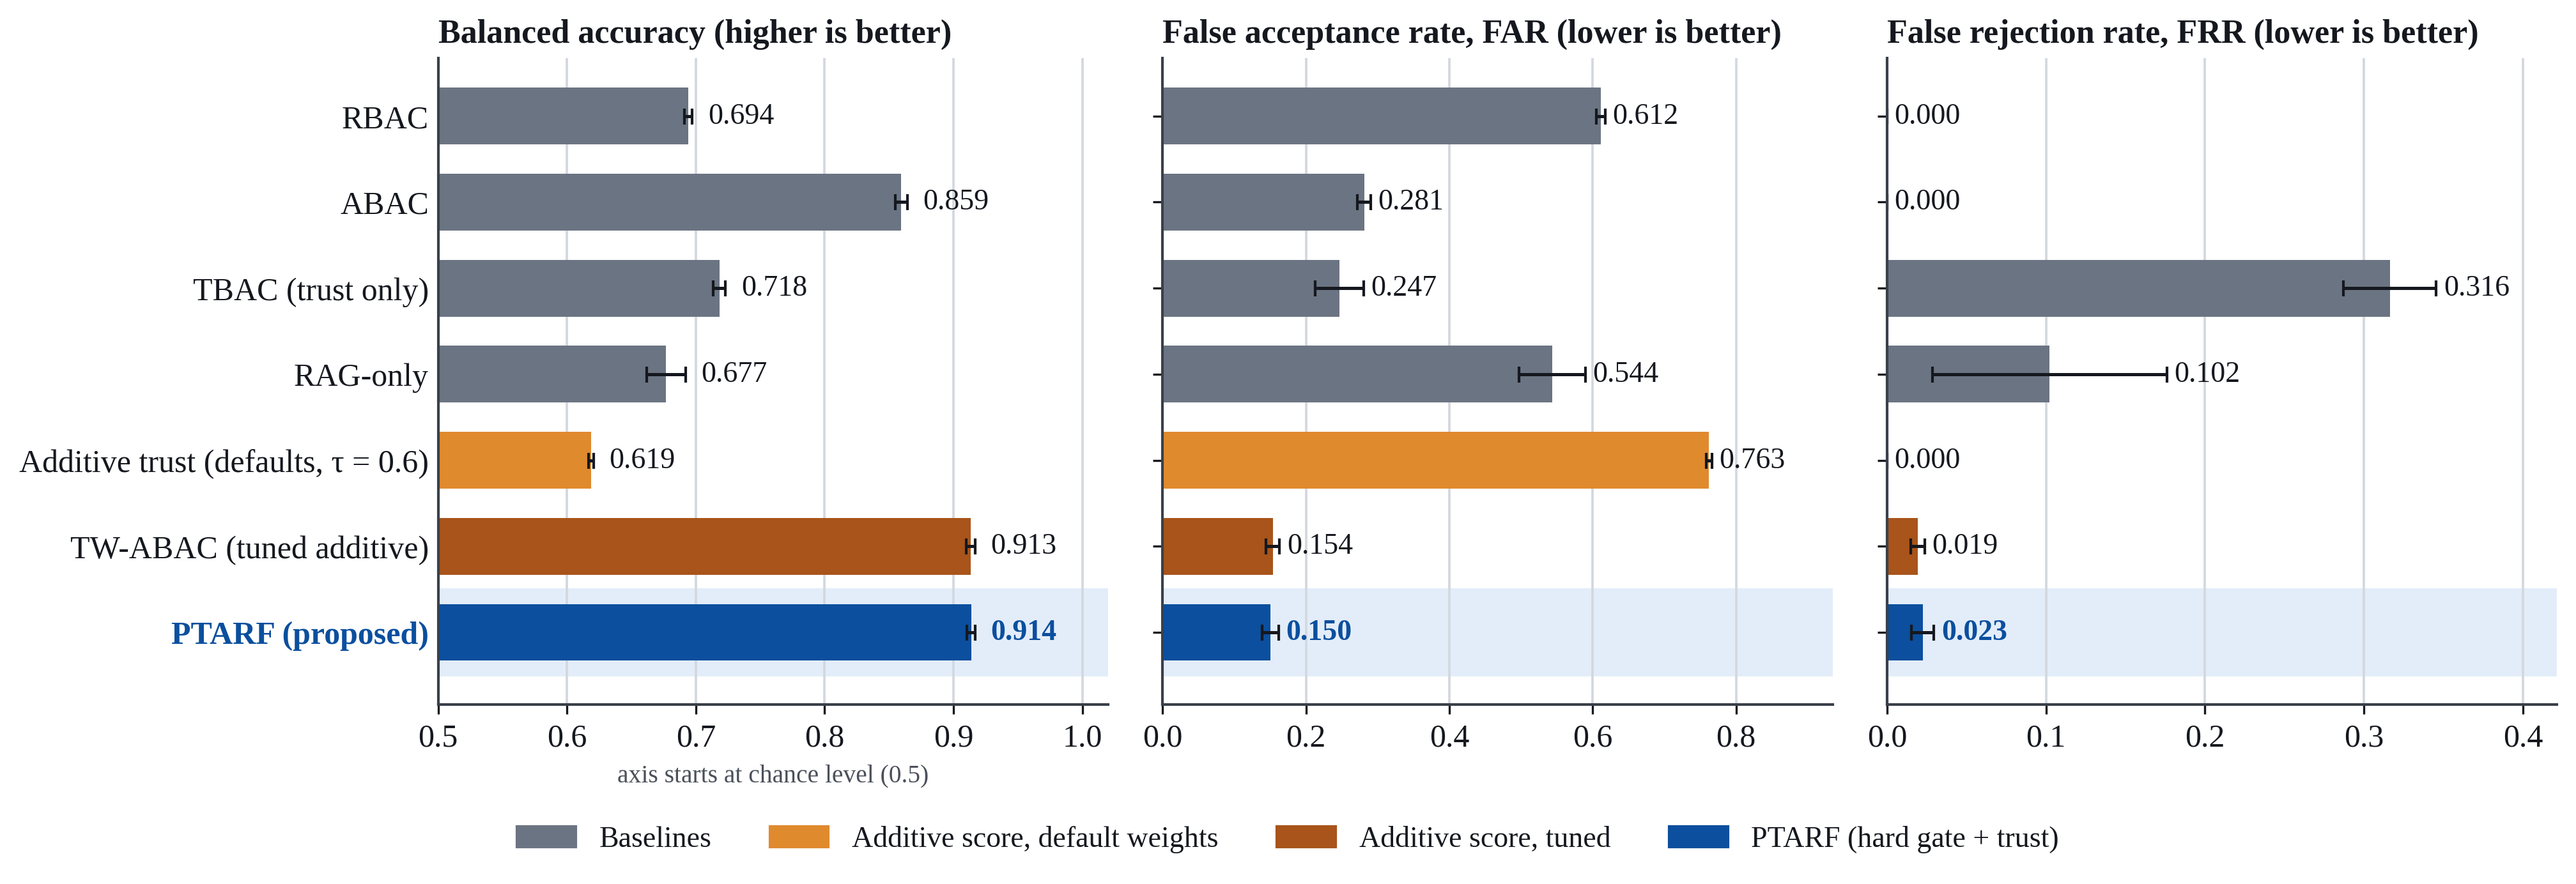

fig_classification_metrics


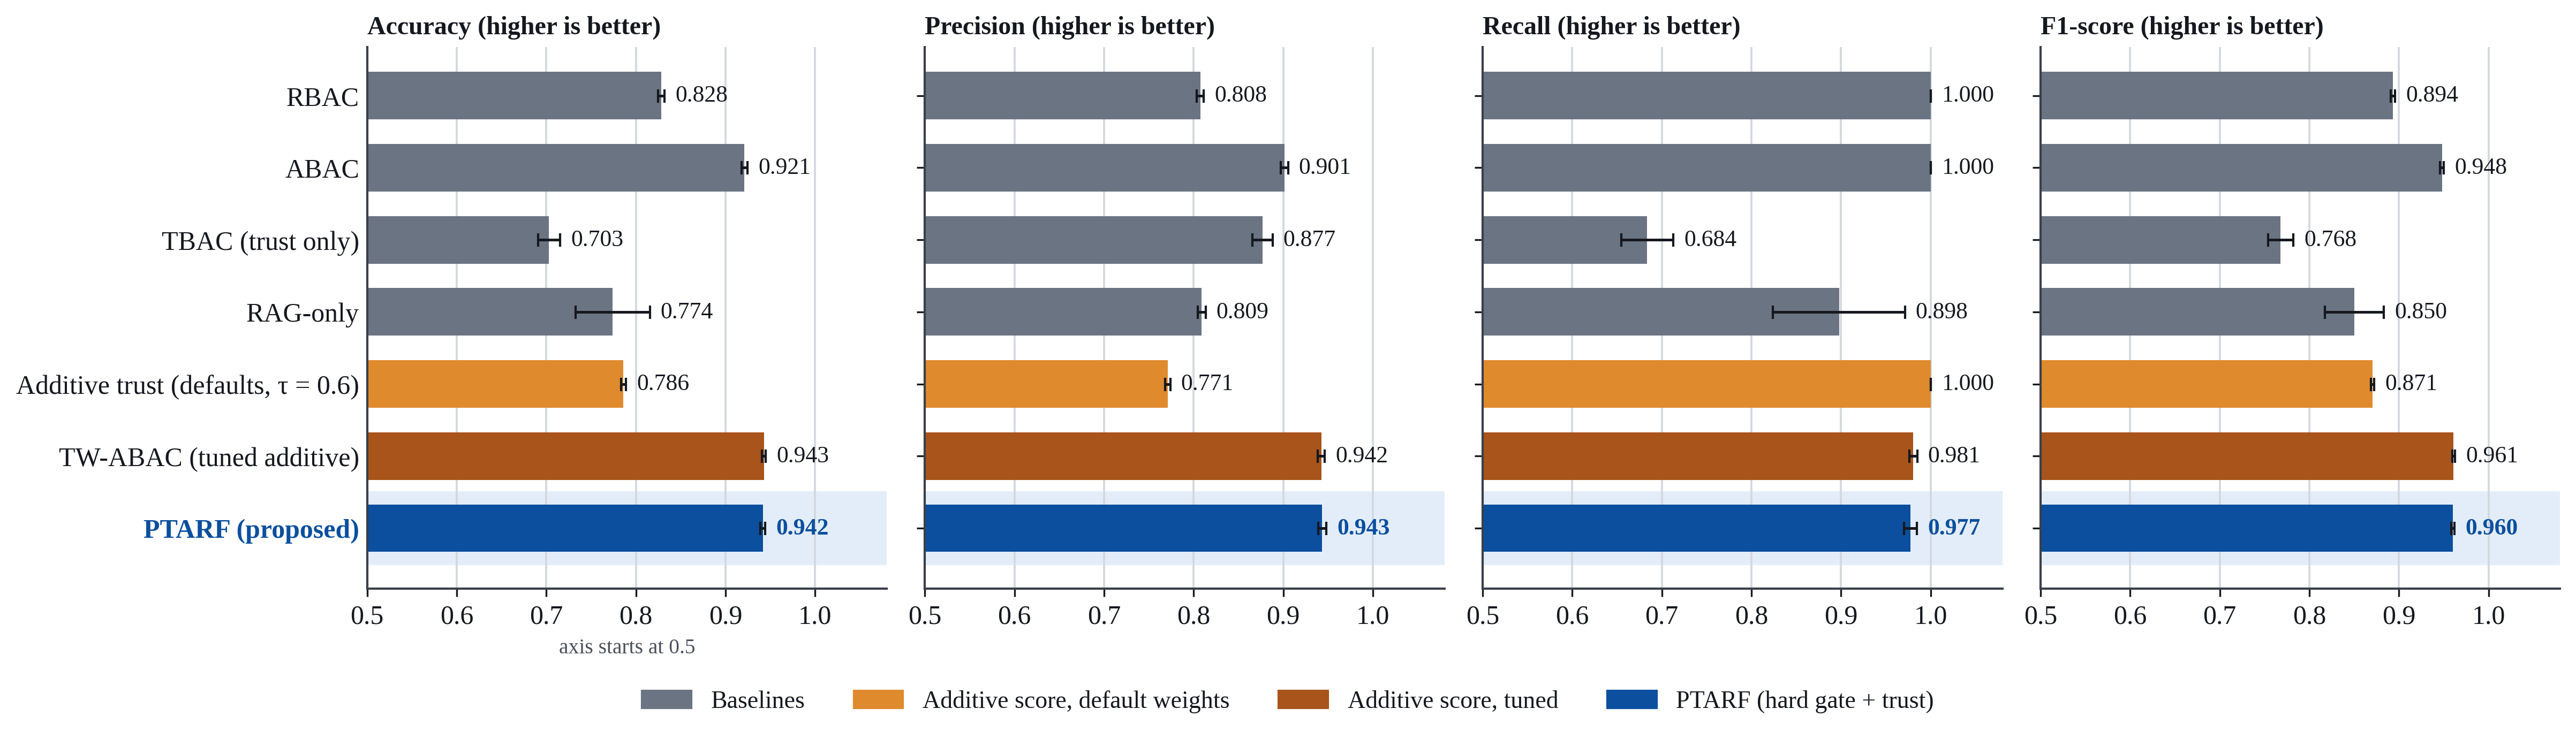

fig_per_scenario


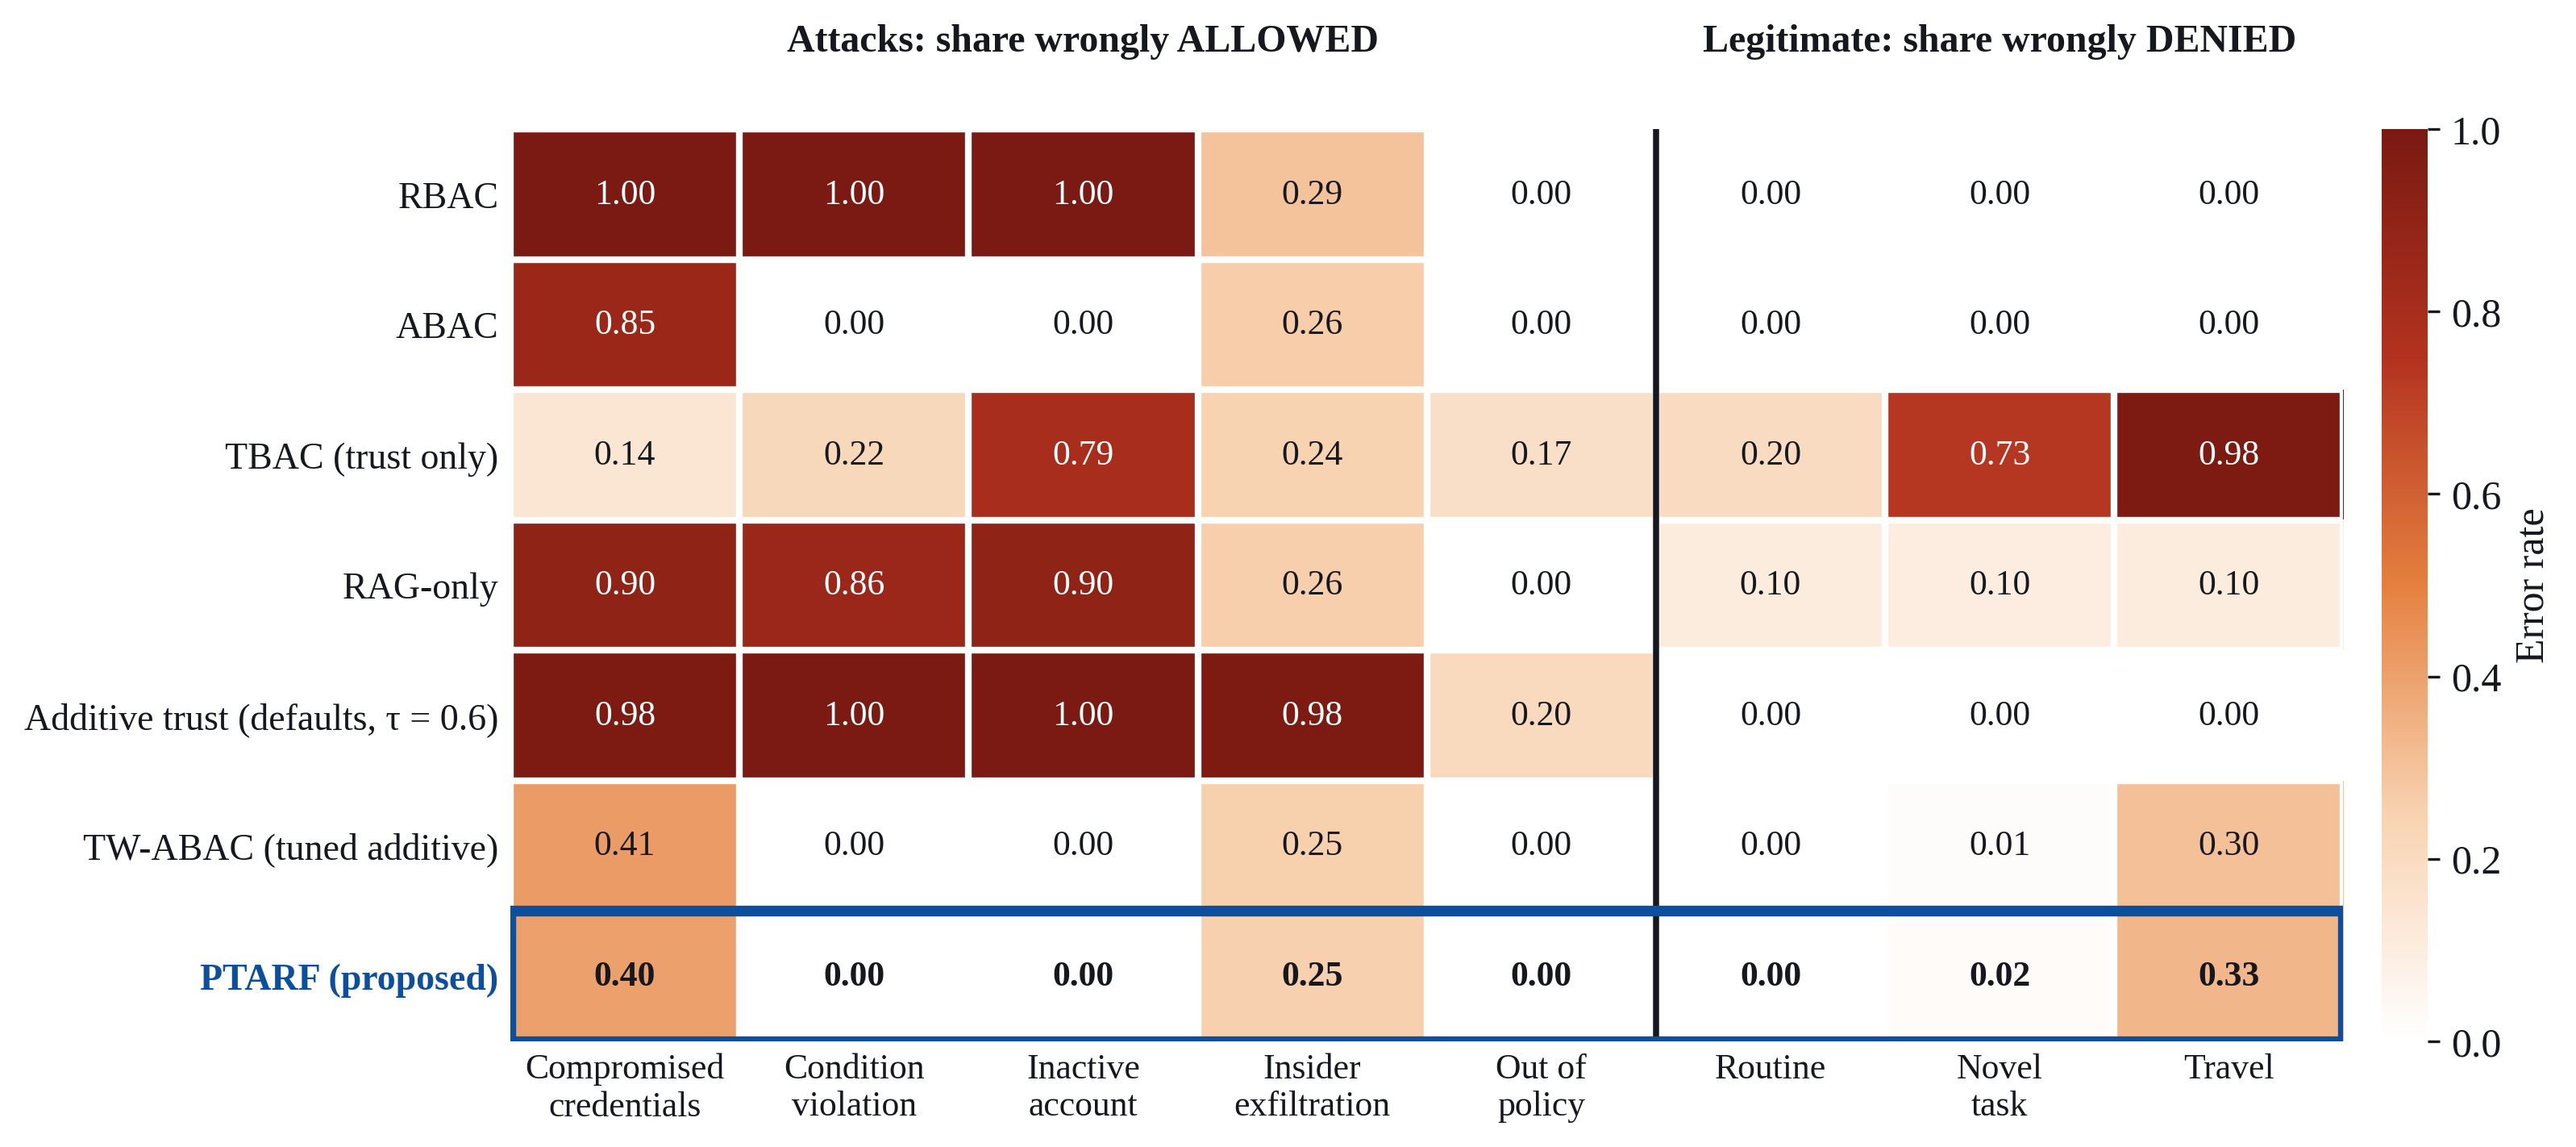

fig_threshold


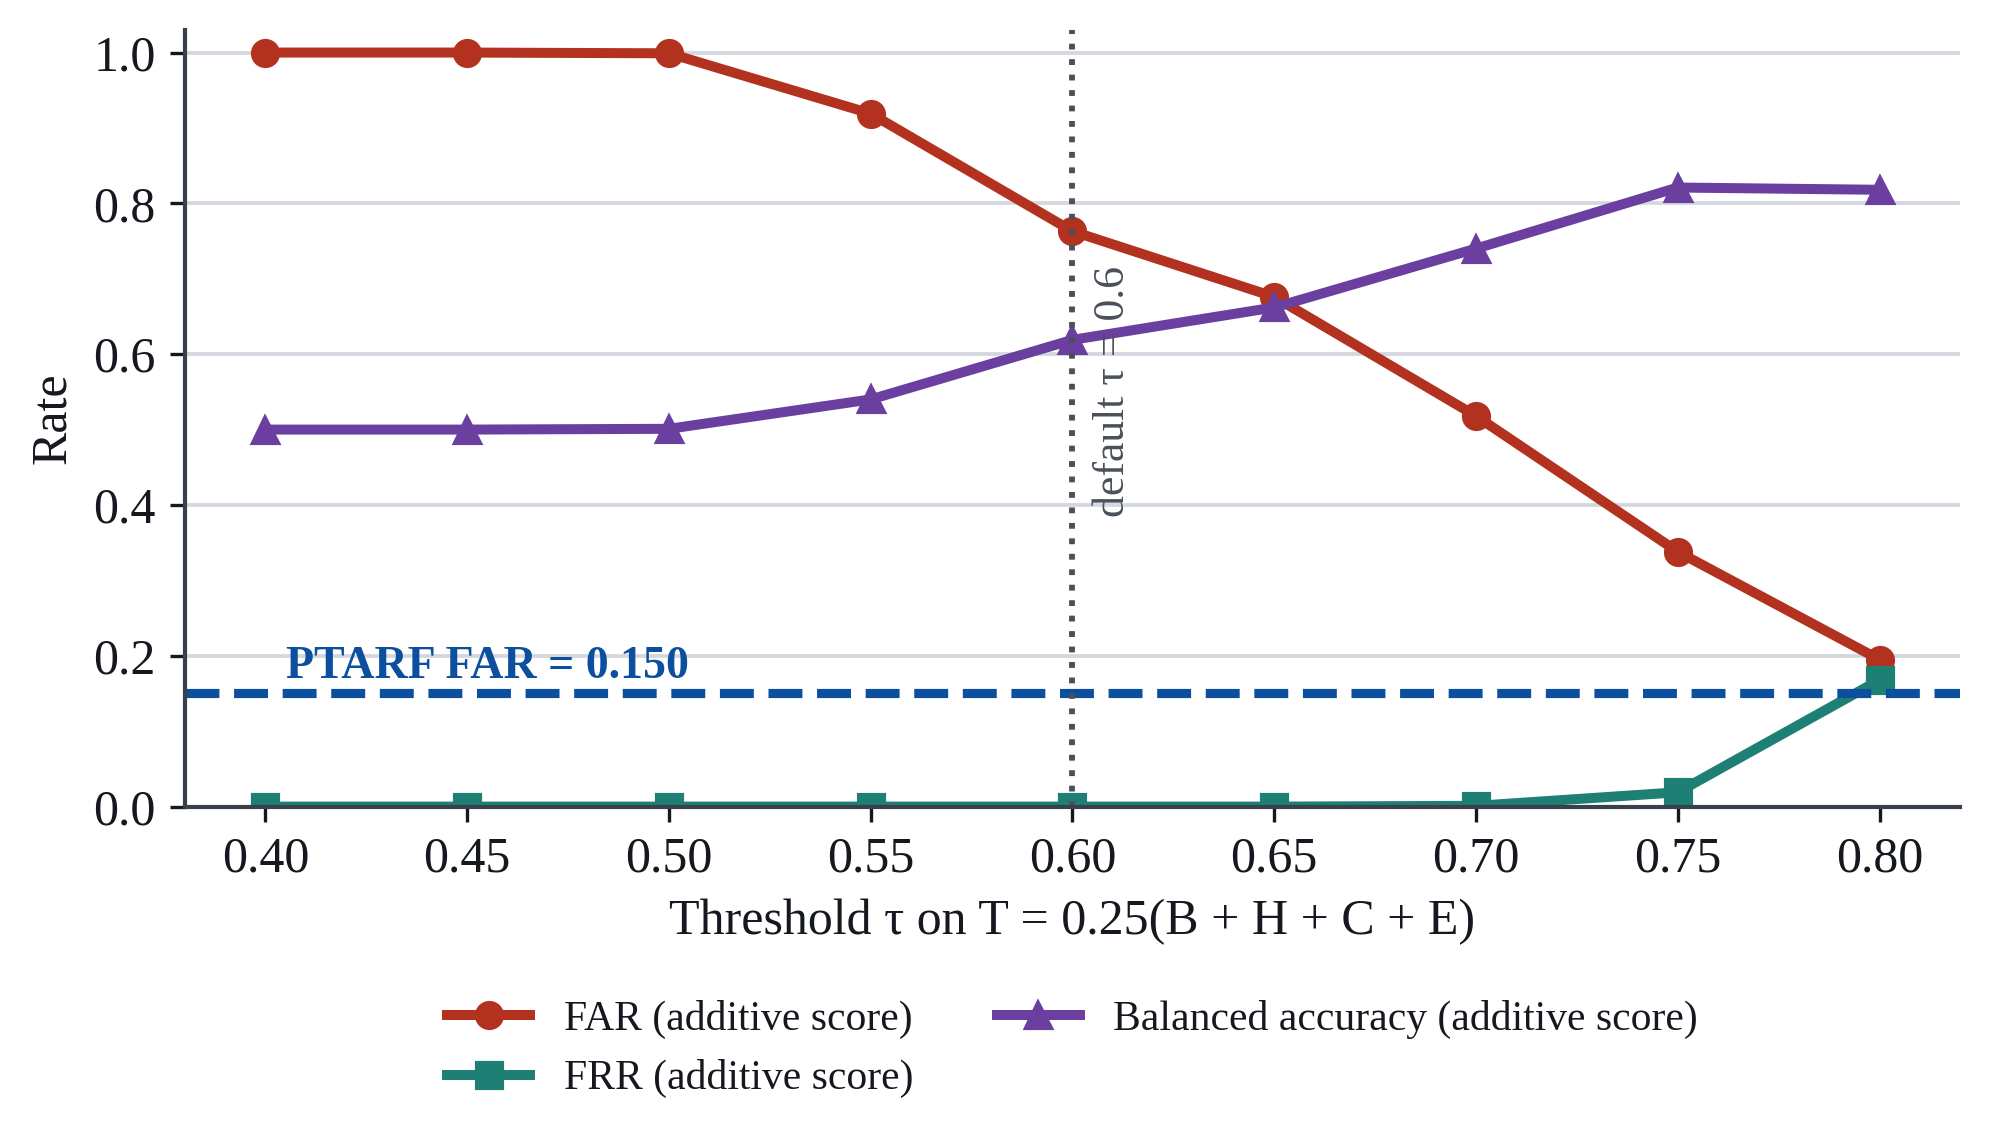

fig_stealth


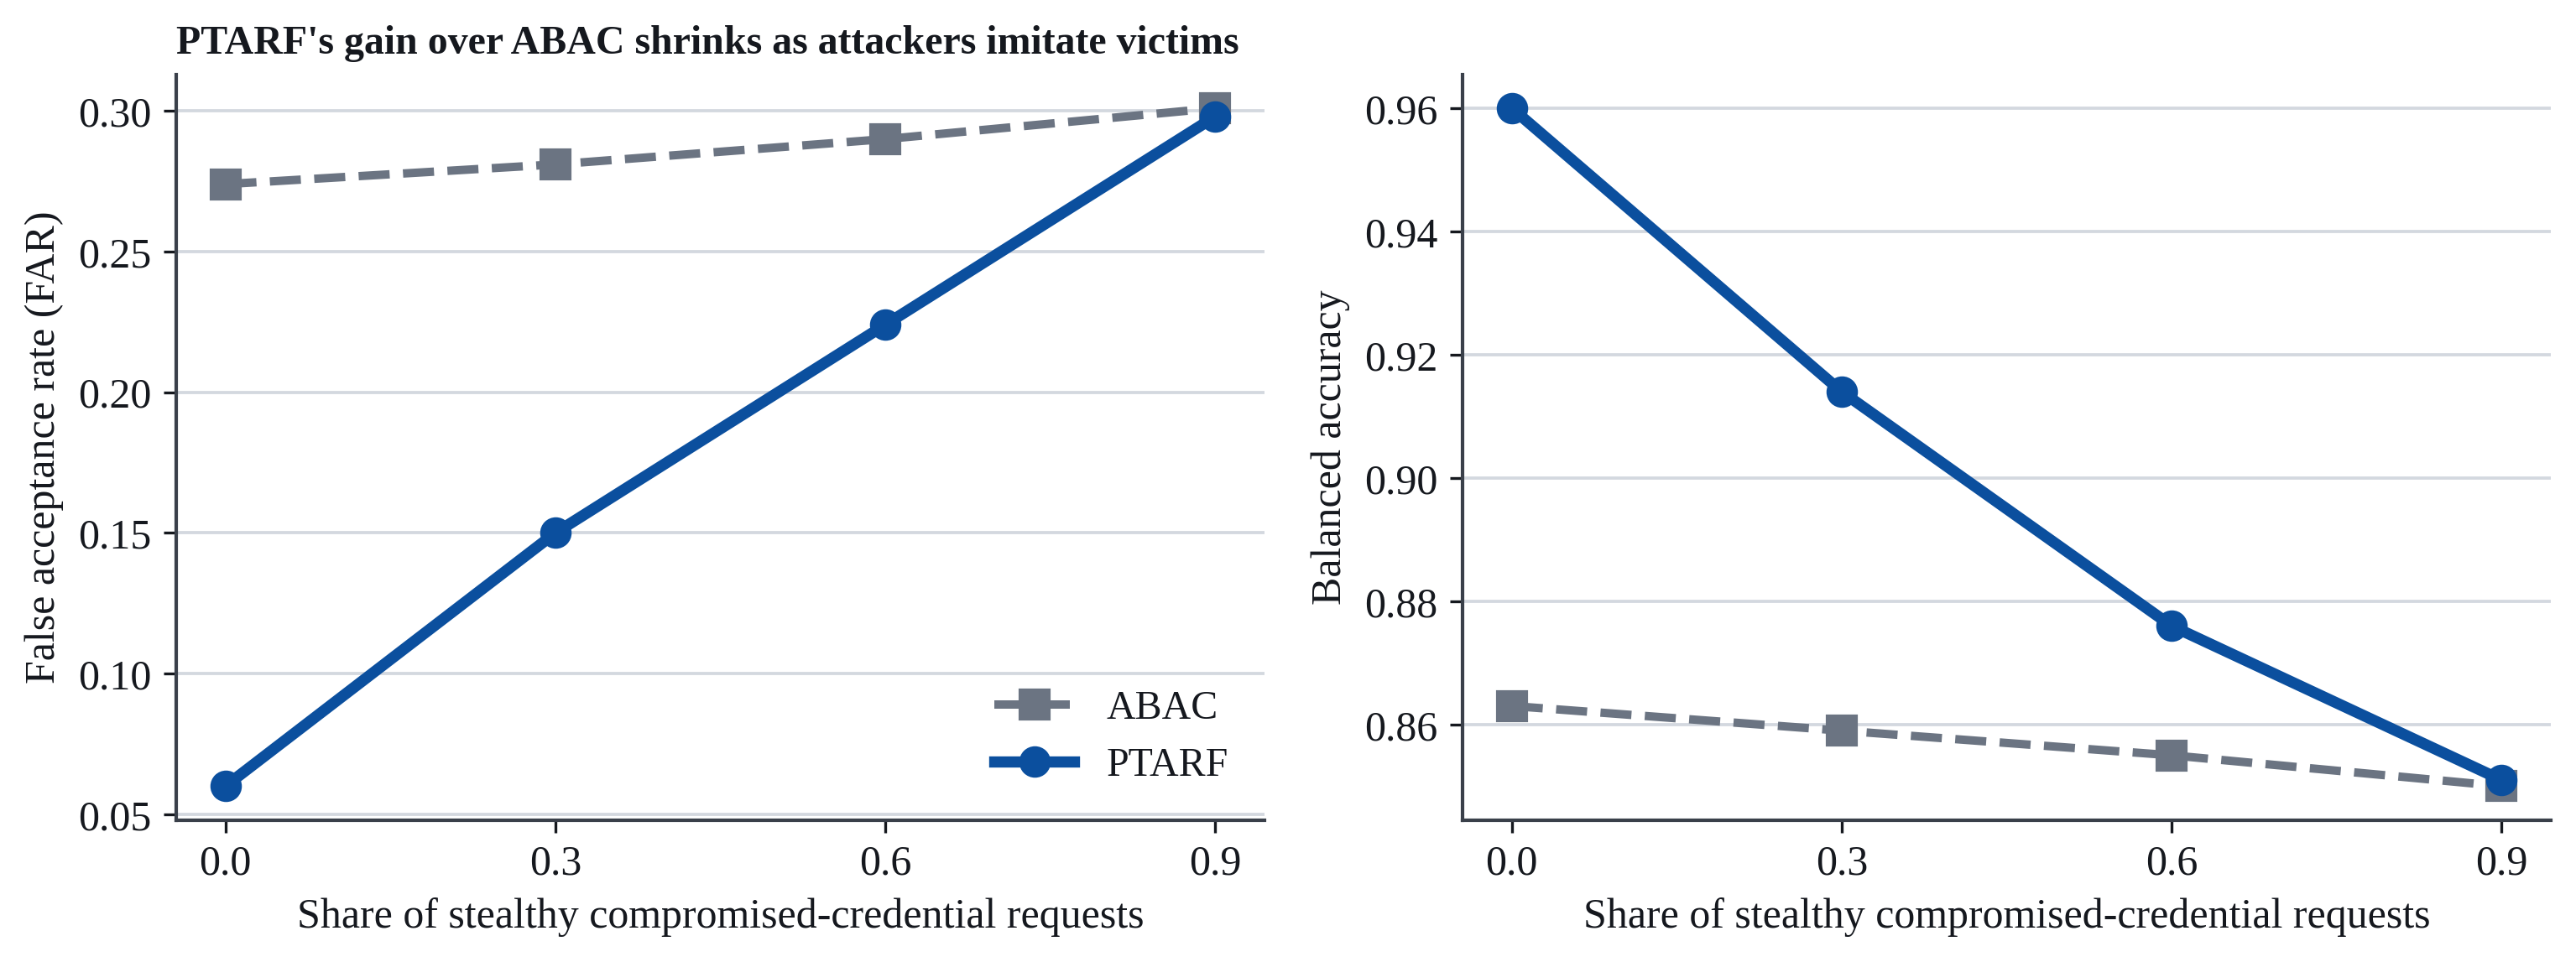

fig_retrieval


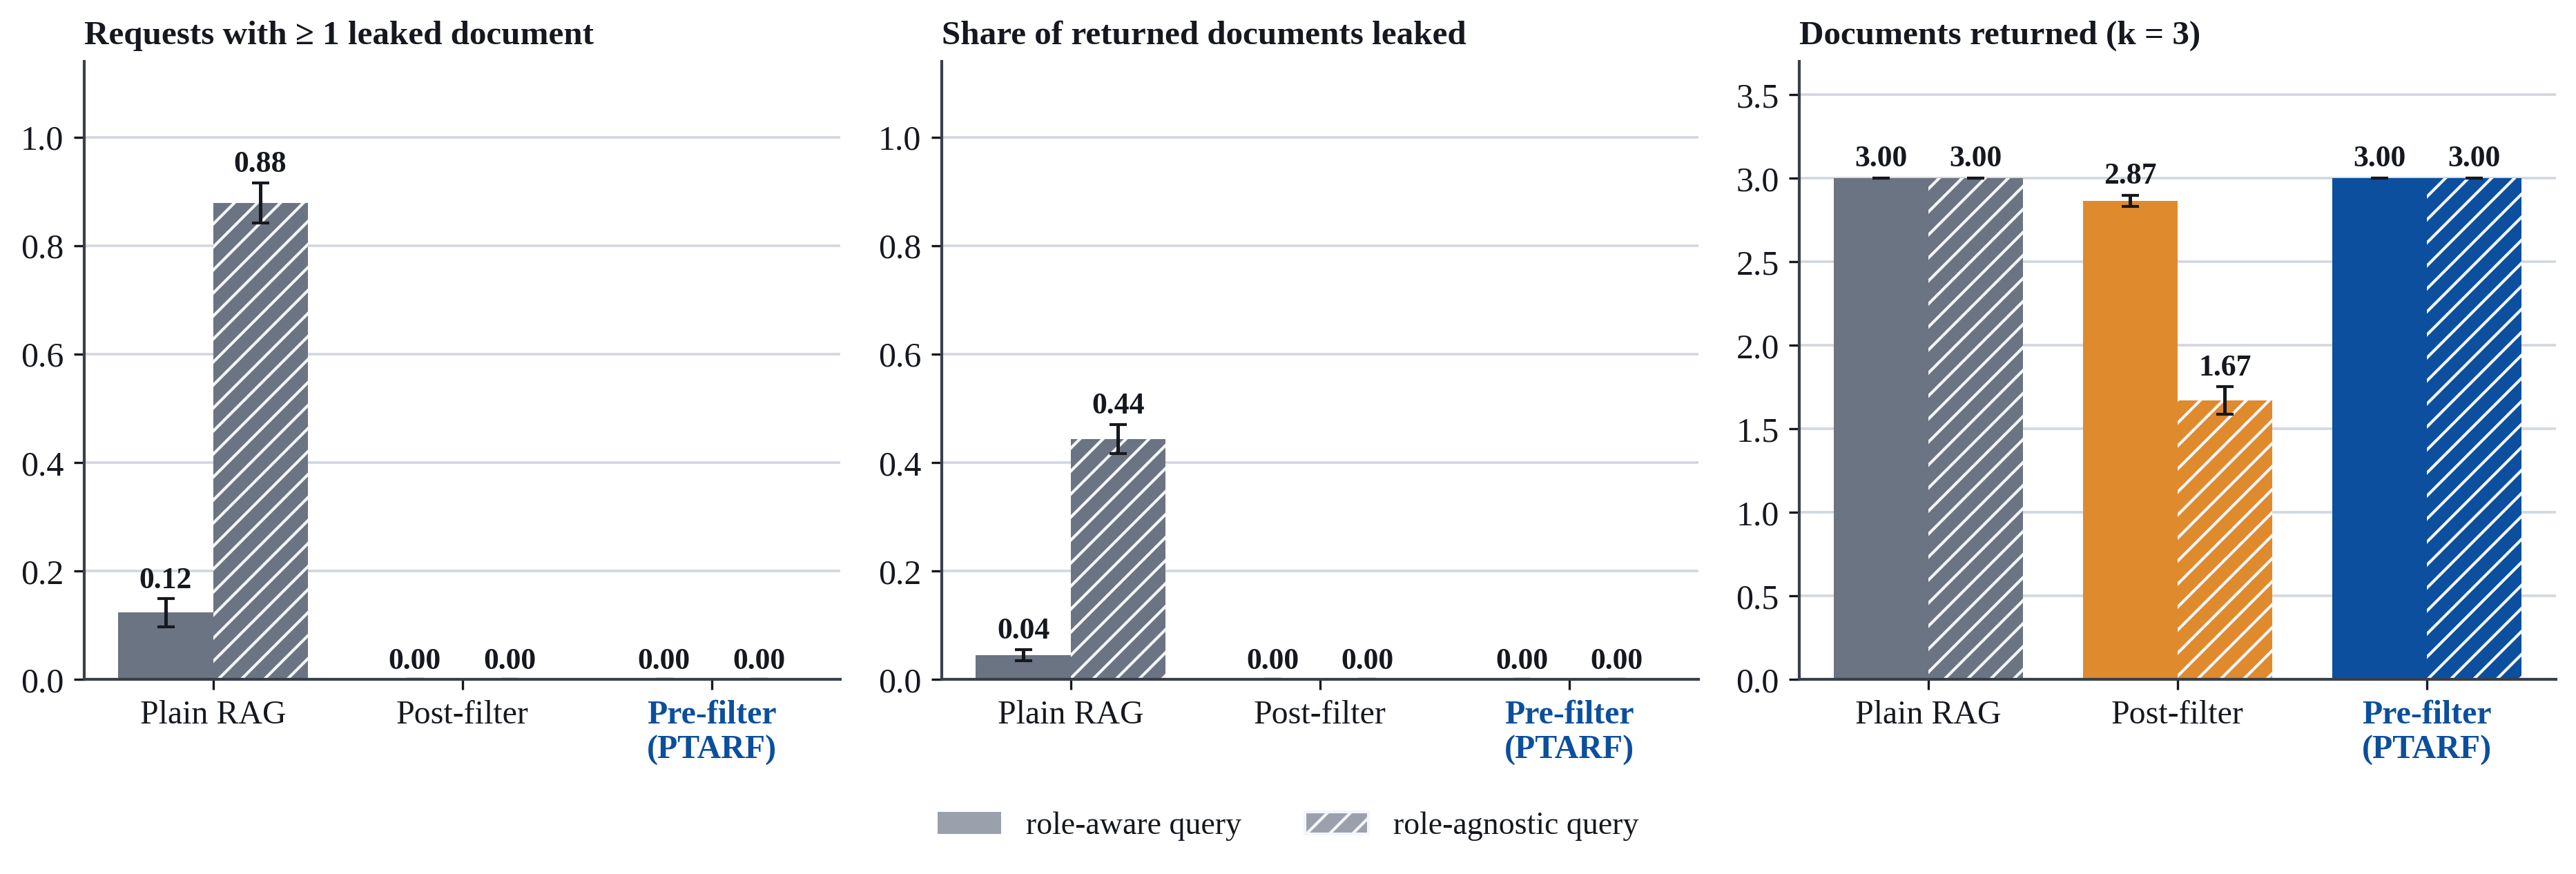

In [33]:
!python make_figs_v3.py
for f in ['fig_main_metrics','fig_classification_metrics','fig_per_scenario','fig_threshold','fig_stealth','fig_retrieval']:
    print(f); display(Image(f'results/{f}.png'))

In [34]:
for f in ['retrieval_summary.csv','monitoring_summary.csv','stealth_sensitivity.csv','threshold_sensitivity_additive_trust.csv']:
    print(f); display(pd.read_csv('results/' + f))
print(json.dumps(json.load(open('results/latency.json')), indent=1)[:900])

retrieval_summary.csv


,query,retriever,leak_rate,leak_docs,n_returned,empty_rate,evidence_recall
0,role-aware,plain,0.124 ± 0.026,0.045 ± 0.011,3.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000
1,role-aware,post-filter,0.000 ± 0.000,0.000 ± 0.000,2.865 ± 0.032,0.000 ± 0.000,1.000 ± 0.000
2,role-aware,pre-filter,0.000 ± 0.000,0.000 ± 0.000,3.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000
3,role-agnostic,plain,0.879 ± 0.037,0.443 ± 0.027,3.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000
4,role-agnostic,post-filter,0.000 ± 0.000,0.000 ± 0.000,1.670 ± 0.082,0.000 ± 0.000,1.000 ± 0.000
5,role-agnostic,pre-filter,0.000 ± 0.000,0.000 ± 0.000,3.000 ± 0.000,0.000 ± 0.000,1.000 ± 0.000


monitoring_summary.csv


,policy,Balanced_Acc,FAR,FRR,err_compromised,err_insider_exfil,err_travel,err_novel_task
0,static,0.914 ± 0.003,0.150 ± 0.012,0.023 ± 0.007,0.401 ± 0.026,0.252 ± 0.047,0.333 ± 0.065,0.021 ± 0.016
1,self-update,0.913 ± 0.003,0.152 ± 0.011,0.021 ± 0.007,0.405 ± 0.025,0.254 ± 0.046,0.330 ± 0.062,0.017 ± 0.015
2,confirmed,0.913 ± 0.003,0.152 ± 0.011,0.021 ± 0.007,0.405 ± 0.025,0.254 ± 0.046,0.328 ± 0.063,0.017 ± 0.014


stealth_sensitivity.csv


,stealth,model,FAR,Balanced_Acc,compromised_allowed
0,0.0,ABAC,0.274,0.863,0.818
1,0.0,LogReg (supervised ref.),0.029,0.976,0.050
2,0.0,PTARF,0.060,0.960,0.086
3,0.3,ABAC,0.281,0.859,0.846
4,0.3,LogReg (supervised ref.),0.116,0.926,0.314
5,0.3,PTARF,0.150,0.914,0.397
6,0.6,ABAC,0.290,0.855,0.880
7,0.6,LogReg (supervised ref.),0.202,0.887,0.611
8,0.6,PTARF,0.224,0.876,0.659
9,0.9,ABAC,0.301,0.850,0.914


threshold_sensitivity_additive_trust.csv


,threshold,Accuracy,Balanced_Acc,FAR,FRR
0,0.40,0.720,0.500,1.000,0.000
1,0.45,0.720,0.500,1.000,0.000
2,0.50,0.720,0.501,0.999,0.000
3,0.55,0.742,0.540,0.919,0.000
4,0.60,0.786,0.619,0.763,0.000
5,0.65,0.810,0.662,0.676,0.000
6,0.70,0.854,0.740,0.518,0.001
7,0.75,0.891,0.821,0.338,0.019
8,0.80,0.824,0.818,0.195,0.168


{
 "gate_ms": {
  "mean": 0.0010184233327284649,
  "p50": 0.0009729999419505475,
  "p95": 0.0015031000202725402,
  "p99": 0.0020990498592254867
 },
 "decision_ms(gate+trust)": {
  "mean": 0.010350149332149764,
  "p50": 0.011792000009336334,
  "p95": 0.015067099832322128,
  "p99": 0.02268752998588744
 },
 "scoped_retrieval_ms": {
  "mean": 0.7825717583320966,
  "p50": 0.7543765000264102,
  "p95": 0.9607871501543739,
  "p99": 1.3181307100921913
 },
 "decision+retrieval_ms": {
  "mean": 0.7929219076642463,
  "p50": 0.7650799999510127,
  "p95": 0.9701589999622228,
  "p99": 1.3250784200363341
 },
 "decision_throughput_req_per_s": 96616.96347643869,
 "decision+retrieval_throughput_req_per_s": 1261.158243118487,
 "index": {
  "n_policy_docs": 194,
  "n_terms": 102,
  "tfidf_matrix_KB": 32.4140625,
  "n_users_profiled": 5000,
  "n_history_events": 200383
 }
}


## Reproducibility check against the manuscript
The dictionary below holds the values **printed in the manuscript** (Table 7 and Table 11). The cell recomputes the same quantities from this run and reports agreement. In `QUICK` mode (2 seeds) the comparison is indicative only, so the tolerance is wider.

In [37]:
d = pd.read_csv('results/per_seed_results.csv'); m = d.groupby('model')[['Balanced_Acc', 'FAR']].mean()
r = pd.read_csv('results/retrieval_per_seed.csv').groupby(['query', 'retriever']).leak_rate.mean()
expected = {   # value printed in the manuscript  ->  value recomputed here
  'ABAC balanced accuracy':            (0.859, m.loc['ABAC', 'Balanced_Acc']),
  'ABAC FAR':                          (0.281, m.loc['ABAC', 'FAR']),
  'PTARF balanced accuracy':           (0.914, m.loc['PTARF', 'Balanced_Acc']),
  'PTARF FAR':                         (0.150, m.loc['PTARF', 'FAR']),
  'Additive trust (tau=0.6) FAR':             (0.763, m.loc['AdditiveTrust-default', 'FAR']),
  'TW-ABAC FAR':                       (0.154, m.loc['TW-ABAC (tuned additive)', 'FAR']),
  'Plain retrieval leak, role-agnostic': (0.879, r[('role-agnostic', 'plain')]),
  'Plain retrieval leak, role-aware':  (0.124, r[('role-aware', 'plain')]),
}
tol = 0.03 if QUICK else 0.01
ok = True
for k, (ref, got) in expected.items():
    flag = 'OK ' if abs(ref - got) <= tol else 'DIFF'; ok &= flag == 'OK '
    print(f'{flag}  {k:<38} manuscript {ref:.3f}   this run {got:.3f}')
print('\nAll values within tolerance' if ok else '\nSome values differ: inspect results/ (different seeds, library versions or QUICK mode)')

OK   ABAC balanced accuracy                 manuscript 0.859   this run 0.859
OK   ABAC FAR                               manuscript 0.281   this run 0.281
OK   PTARF balanced accuracy                manuscript 0.914   this run 0.914
OK   PTARF FAR                              manuscript 0.150   this run 0.150
OK   Additive trust (tau=0.6) FAR           manuscript 0.763   this run 0.763
OK   TW-ABAC FAR                            manuscript 0.154   this run 0.154
OK   Plain retrieval leak, role-agnostic    manuscript 0.879   this run 0.879
OK   Plain retrieval leak, role-aware       manuscript 0.124   this run 0.124

All values within tolerance


In [36]:
import shutil; shutil.make_archive('PTARF_results', 'zip', 'results'); print('Download PTARF_results.zip from the Files panel.')

Download PTARF_results.zip from the Files panel.
